In [ ]:
# ============================================================
# DINOv2 + Supervised Contrastive Learning
# ============================================================

# Install required packages
!pip -q install transformers umap-learn scikit-learn seaborn

# ============================================================
# Imports
# ============================================================

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import umap.umap_ as umap

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================================
# CELL 2 — REPRODUCIBILITY & DEVICE CONFIGURATION
# ============================================================

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Reproducibility settings
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed:", SEED)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU Memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Seed: 42
Device: cuda
GPU: Tesla T4
GPU Memory: 14.56 GB


In [ ]:
# Download Dataset

!pip -q install kagglehub
import kagglehub

# Download the latest version of the dataset
dataset_path = kagglehub.dataset_download(
    "ajg117/indian-paintings-dataset"
)

print("Dataset path:")
print(dataset_path)

100%|██████████| 355M/355M [00:18<00:00, 20.1MB/s]

Extracting files...


Dataset path:
/root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3


In [ ]:
# ============================================================
# CELL 4 — INSPECT DATASET STRUCTURE
# ============================================================

import os

print("Dataset root:")
print(dataset_path)
print("\n" + "=" * 70)

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    # Show files only for the current directory
    if files:
        for file in files[:10]:
            print(f"{indent}    {file}")

        if len(files) > 10:
            print(f"{indent}    ... ({len(files)} files total)")

Dataset root:
/root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3

3/
    LICENSE
    classes.csv
    pichwai painting/
        pichwai70.jpeg
        pichwai51.jpg
        pichwai76.jpg
        pichwai83.jpg
        pichwai5.jpg
        pichwai30.jpeg
        pichwai86.jpg
        pichwai58.jpg
        pichwai23.jpg
        pichwai20.jpg
        ... (97 files total)
    gond painting/
        gond46.jpg
        gond32.jpg
        gond84.jpg
        gond83.jpg
        gond35.jpg
        gond89.jpeg
        gond70.jpg
        gond50.jpg
        gond17.jpg
        gond11.jpg
        ... (101 files total)
    kerala mural/
        kerala69.jpeg
        kerala29.jpg
        kerala19.jpg
        kerala82.jpg
        kerala30.jpg
        kerala38.jpg
        kerala13.jpg
        kerala62.jpg
        kerala65.jpg
        kerala26.jpg
        ... (95 files total)
    kangra painting/
        kangra52.jpg
        kangra53.jpg
        kangra54.jpg
        kangra75.png
    

In [ ]:
# ============================================================
# CELL 5 — LOCATE IMAGE DATA DIRECTORY
# ============================================================

from pathlib import Path

dataset_root = Path(dataset_path)

# Common image extensions
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".webp", ".tif", ".tiff"
}

# Find directories that directly contain image files
candidate_dirs = []

for root, dirs, files in os.walk(dataset_root):
    image_files = [
        f for f in files
        if Path(f).suffix.lower() in IMAGE_EXTENSIONS
    ]

    if image_files:
        candidate_dirs.append({
            "path": root,
            "image_count": len(image_files),
            "sample_files": image_files[:3]
        })

print("=" * 80)
print("IMAGE-DIRECTORY INSPECTION")
print("=" * 80)

for item in candidate_dirs:
    print(f"\nDirectory: {item['path']}")
    print(f"Images:    {item['image_count']}")
    print(f"Samples:   {item['sample_files']}")

print("\nTotal directories containing images:", len(candidate_dirs))

IMAGE-DIRECTORY INSPECTION

Directory: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/pichwai painting
Images:    96
Samples:   ['pichwai70.jpeg', 'pichwai51.jpg', 'pichwai76.jpg']

Directory: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/gond painting
Images:    98
Samples:   ['gond46.jpg', 'gond32.jpg', 'gond84.jpg']

Directory: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/kerala mural
Images:    94
Samples:   ['kerala69.jpeg', 'kerala29.jpg', 'kerala19.jpg']

Directory: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/kangra painting
Images:    87
Samples:   ['kangra52.jpg', 'kangra53.jpg', 'kangra54.jpg']

Directory: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3/mandana art drawing
Images:    140
Samples:   ['mandana124.jpg', 'mandana107.jpg', 'mandana130.png']

Directory: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versio

In [ ]:
# ============================================================
# CELL 6 — CLASS DISCOVERY & CLASS DISTRIBUTION
# ============================================================

from collections import Counter
from pathlib import Path

# Find directories that contain images directly
class_dirs = []

for root, dirs, files in os.walk(dataset_path):
    image_files = [
        f for f in files
        if Path(f).suffix.lower() in IMAGE_EXTENSIONS
    ]

    if image_files:
        class_dirs.append(Path(root))

# Sort for reproducibility
class_dirs = sorted(class_dirs)

# ------------------------------------------------------------
# Identify class directories
# ------------------------------------------------------------

class_names = [path.name for path in class_dirs]

print("=" * 80)
print("DISCOVERED CLASSES")
print("=" * 80)

for idx, (name, path) in enumerate(zip(class_names, class_dirs)):
    count = sum(
        1 for f in path.iterdir()
        if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(f"{idx:2d}. {name:<30} {count:>5} images")

print("\n" + "=" * 80)
print("DATASET SUMMARY")
print("=" * 80)

print("Number of classes:", len(class_names))
print("Total images:", sum(
    1 for class_dir in class_dirs
    for f in class_dir.iterdir()
    if f.is_file() and f.suffix.lower() in IMAGE_EXTENSIONS
))

DISCOVERED CLASSES
 0. gond painting                     98 images
 1. kalighat painting                244 images
 2. kangra painting                   87 images
 3. kerala mural                      94 images
 4. madhubani painting                95 images
 5. mandana art drawing              140 images
 6. pichwai painting                  96 images
 7. warli painting                    97 images

DATASET SUMMARY
Number of classes: 8
Total images: 951


In [ ]:
# ============================================================
# CELL 7 — BUILD IMAGE METADATA & VALIDATE FILES
# ============================================================

from PIL import Image

records = []

for class_idx, class_dir in enumerate(class_dirs):

    for file_path in sorted(class_dir.iterdir()):

        if not file_path.is_file():
            continue

        if file_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        records.append({
            "image_path": str(file_path),
            "class_name": class_dir.name,
            "class_idx": class_idx
        })


df = pd.DataFrame(records)

print("=" * 80)
print("IMAGE METADATA")
print("=" * 80)

print("Total images:", len(df))
print("Total classes:", df["class_name"].nunique())

print("\nClass distribution:")
print(df["class_name"].value_counts().sort_index())


# ============================================================
# CHECK FOR CORRUPTED / UNREADABLE IMAGES
# ============================================================

bad_files = []

for image_path in df["image_path"]:

    try:
        with Image.open(image_path) as img:
            img.verify()

    except Exception as e:
        bad_files.append({
            "image_path": image_path,
            "error": str(e)
        })


print("\n" + "=" * 80)
print("FILE VALIDATION")
print("=" * 80)

print("Total files checked:", len(df))
print("Unreadable/corrupted files:", len(bad_files))

if bad_files:
    print("\nProblematic files:")
    for item in bad_files[:20]:
        print(item["image_path"])
else:
    print("All images passed the integrity check.")

IMAGE METADATA
Total images: 951
Total classes: 8

Class distribution:
class_name
gond painting           98
kalighat painting      244
kangra painting         87
kerala mural            94
madhubani painting      95
mandana art drawing    140
pichwai painting        96
warli painting          97
Name: count, dtype: int64

FILE VALIDATION
Total files checked: 951
Unreadable/corrupted files: 0
All images passed the integrity check.


In [ ]:
# ============================================================
# CELL 8 — CLEAN MANIFEST & STRATIFIED DATA SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Remove corrupted/unreadable files
# ------------------------------------------------------------

if bad_files:
    bad_paths = {item["image_path"] for item in bad_files}

    df = df[~df["image_path"].isin(bad_paths)].reset_index(drop=True)

print("Valid images remaining:", len(df))


# ------------------------------------------------------------
# Create stratified train/test split
# ------------------------------------------------------------

train_val_df, test_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["class_idx"],
    random_state=SEED
)


# ------------------------------------------------------------
# Split remaining data into train/validation
#
# 15% validation of the original dataset:
# 0.15 / 0.85 = 0.17647
# ------------------------------------------------------------

train_df, val_df = train_test_split(
    train_val_df,
    test_size=(0.15 / 0.85),
    stratify=train_val_df["class_idx"],
    random_state=SEED
)


# ------------------------------------------------------------
# Reset indices
# ------------------------------------------------------------

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# ------------------------------------------------------------
# Display split sizes
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("DATASET SPLIT")
print("=" * 80)

print(f"Train      : {len(train_df):>5} ({len(train_df)/len(df)*100:.2f}%)")
print(f"Validation : {len(val_df):>5} ({len(val_df)/len(df)*100:.2f}%)")
print(f"Test       : {len(test_df):>5} ({len(test_df)/len(df)*100:.2f}%)")


# ------------------------------------------------------------
# Verify class distribution across splits
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASS DISTRIBUTION BY SPLIT")
print("=" * 80)

distribution = pd.DataFrame({
    "Train": train_df["class_name"].value_counts(),
    "Validation": val_df["class_name"].value_counts(),
    "Test": test_df["class_name"].value_counts()
}).fillna(0).astype(int)

distribution["Total"] = (
    distribution["Train"]
    + distribution["Validation"]
    + distribution["Test"]
)

print(distribution.sort_index())

Valid images remaining: 951

DATASET SPLIT
Train      :   665 (69.93%)
Validation :   143 (15.04%)
Test       :   143 (15.04%)

CLASS DISTRIBUTION BY SPLIT
                     Train  Validation  Test  Total
class_name                                         
gond painting           68          15    15     98
kalighat painting      170          37    37    244
kangra painting         61          13    13     87
kerala mural            66          14    14     94
madhubani painting      67          14    14     95
mandana art drawing     98          21    21    140
pichwai painting        67          15    14     96
warli painting          68          14    15     97


DATA SPLIT INTEGRITY
Train ↔ Validation overlap : 0
Train ↔ Test overlap       : 0
Validation ↔ Test overlap  : 0

✓ No image overlap detected.

CLASS PRESENCE CHECK
Train: 8/8 classes
  ✓ All classes present
Validation: 8/8 classes
  ✓ All classes present
Test: 8/8 classes
  ✓ All classes present

VISUAL SAMPLE INSPECTION


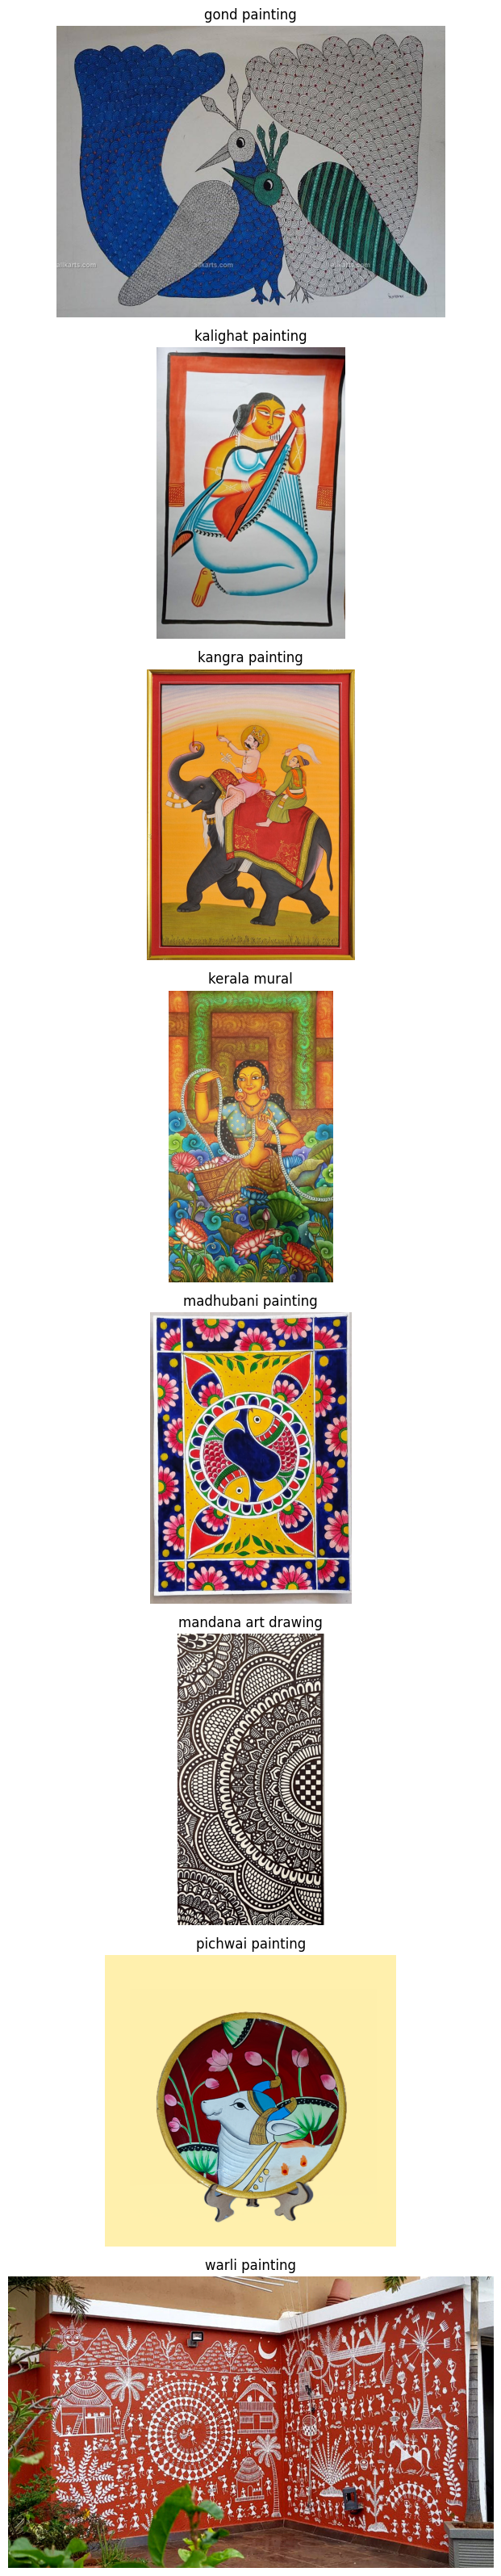

In [ ]:
# ============================================================
# CELL 9 — SPLIT INTEGRITY & SAMPLE INSPECTION
# ============================================================

# ------------------------------------------------------------
# 1. Check for image overlap
# ------------------------------------------------------------

train_paths = set(train_df["image_path"])
val_paths   = set(val_df["image_path"])
test_paths  = set(test_df["image_path"])

train_val_overlap = train_paths & val_paths
train_test_overlap = train_paths & test_paths
val_test_overlap = val_paths & test_paths

print("=" * 80)
print("DATA SPLIT INTEGRITY")
print("=" * 80)

print("Train ↔ Validation overlap :", len(train_val_overlap))
print("Train ↔ Test overlap       :", len(train_test_overlap))
print("Validation ↔ Test overlap  :", len(val_test_overlap))

if not train_val_overlap and not train_test_overlap and not val_test_overlap:
    print("\n✓ No image overlap detected.")
else:
    print("\n⚠ WARNING: Image overlap detected!")


# ------------------------------------------------------------
# 2. Check class presence in every split
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("CLASS PRESENCE CHECK")
print("=" * 80)

all_classes = set(df["class_name"].unique())

for split_name, split_df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    split_classes = set(split_df["class_name"].unique())
    missing_classes = all_classes - split_classes

    print(f"{split_name}: {len(split_classes)}/{len(all_classes)} classes")

    if missing_classes:
        print("  Missing:", sorted(missing_classes))
    else:
        print("  ✓ All classes present")


# ------------------------------------------------------------
# 3. Display random samples from each class
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("VISUAL SAMPLE INSPECTION")
print("=" * 80)

n_classes_to_show = len(class_names)

fig, axes = plt.subplots(
    nrows=n_classes_to_show,
    ncols=1,
    figsize=(8, 4 * n_classes_to_show)
)

# Handle single-class edge case
if n_classes_to_show == 1:
    axes = [axes]

for ax, class_name in zip(axes, sorted(class_names)):

    class_samples = train_df[
        train_df["class_name"] == class_name
    ]

    sample = class_samples.sample(
        n=1,
        random_state=SEED
    ).iloc[0]

    image = Image.open(sample["image_path"]).convert("RGB")

    ax.imshow(image)
    ax.set_title(class_name, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 10 — DINOv2 PREPROCESSING & DATASET CLASSES
# ============================================================

from PIL import Image
from torch.utils.data import Dataset, DataLoader


# ============================================================
# DINOv2 IMAGE SIZE
# ============================================================

IMAGE_SIZE = 224


# ============================================================
# NORMALIZATION
# DINOv2 uses ImageNet-style normalization
# ============================================================

DINO_MEAN = (0.485, 0.456, 0.406)
DINO_STD = (0.229, 0.224, 0.225)


# ============================================================
# VALIDATION / TEST TRANSFORM
# Deterministic preprocessing
# ============================================================

eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=InterpolationMode.BICUBIC
    ),
    transforms.ToTensor(),
    transforms.Normalize(DINO_MEAN, DINO_STD)
])


# ============================================================
# TRAINING TRANSFORM
# Conservative augmentation for painting images
# ============================================================

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.0),
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
        degrees=10,
        interpolation=InterpolationMode.BICUBIC
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        DINO_MEAN,
        DINO_STD
    )
])


# ============================================================
# SINGLE-VIEW DATASET
# Used for:
# - Frozen DINOv2 baseline
# - MLP baseline
# - Validation
# - Test
# ============================================================

class PaintingDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = int(row["class_idx"])

        return image, label


# ============================================================
# TWO-VIEW DATASET
# Used for Supervised Contrastive Learning
# ============================================================

class ContrastivePaintingDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        # Two independent augmented views
        view_1 = self.transform(image)
        view_2 = self.transform(image)

        label = int(row["class_idx"])

        return view_1, view_2, label


print("Image size:", IMAGE_SIZE)
print("Training transform:", train_transform)
print("Evaluation transform:", eval_transform)
print("Dataset classes created successfully.")

Image size: 224
Training transform: Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), ratio=(0.75, 1.3333), interpolation=bicubic, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=bicubic, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
Evaluation transform: Compose(
    Resize(size=(224, 224), interpolation=bicubic, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)
Dataset classes created successfully.


In [ ]:
# ============================================================
# CELL 11 — DATALOADERS + CLASS-BALANCED BATCH SAMPLER
# ============================================================

from torch.utils.data import Sampler
import math


# ============================================================
# CONFIGURATION
# ============================================================

NUM_WORKERS = 2

# Number of classes sampled per batch
CLASSES_PER_BATCH = min(8, len(class_names))

# Number of images from each selected class
SAMPLES_PER_CLASS = 4

BATCH_SIZE = CLASSES_PER_BATCH * SAMPLES_PER_CLASS

print("=" * 80)
print("DATALOADER CONFIGURATION")
print("=" * 80)

print("Classes per batch :", CLASSES_PER_BATCH)
print("Samples per class :", SAMPLES_PER_CLASS)
print("Batch size        :", BATCH_SIZE)


# ============================================================
# CLASS-BALANCED BATCH SAMPLER
# ============================================================

class BalancedBatchSampler(Sampler):

    def __init__(
        self,
        dataframe,
        classes_per_batch,
        samples_per_class,
        seed=42
    ):

        self.dataframe = dataframe.reset_index(drop=True)

        self.classes_per_batch = classes_per_batch
        self.samples_per_class = samples_per_class
        self.batch_size = (
            classes_per_batch * samples_per_class
        )

        self.seed = seed
        self.epoch = 0

        # Map class → dataset indices
        self.class_to_indices = {}

        for class_idx in sorted(
            self.dataframe["class_idx"].unique()
        ):

            indices = self.dataframe.index[
                self.dataframe["class_idx"] == class_idx
            ].tolist()

            self.class_to_indices[int(class_idx)] = indices

        self.classes = sorted(
            self.class_to_indices.keys()
        )

        # Approximate number of complete batches
        self.num_batches = max(
            1,
            len(self.dataframe) // self.batch_size
        )


    def __iter__(self):

        rng = random.Random(
            self.seed + self.epoch
        )

        for _ in range(self.num_batches):

            # Randomly select classes
            selected_classes = rng.sample(
                self.classes,
                self.classes_per_batch
            )

            batch = []

            for class_idx in selected_classes:

                available_indices = (
                    self.class_to_indices[class_idx]
                )

                # Sampling with replacement if necessary
                if len(available_indices) >= self.samples_per_class:

                    selected_indices = rng.sample(
                        available_indices,
                        self.samples_per_class
                    )

                else:

                    selected_indices = [
                        rng.choice(available_indices)
                        for _ in range(self.samples_per_class)
                    ]

                batch.extend(selected_indices)

            rng.shuffle(batch)

            yield batch

        self.epoch += 1


    def __len__(self):
        return self.num_batches


# ============================================================
# DATASETS
# ============================================================

train_dataset = PaintingDataset(
    train_df,
    transform=train_transform
)

val_dataset = PaintingDataset(
    val_df,
    transform=eval_transform
)

test_dataset = PaintingDataset(
    test_df,
    transform=eval_transform
)

contrastive_train_dataset = ContrastivePaintingDataset(
    train_df,
    transform=train_transform
)


# ============================================================
# STANDARD DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# CONTRASTIVE BALANCED BATCH LOADER
# ============================================================

balanced_sampler = BalancedBatchSampler(
    dataframe=train_df,
    classes_per_batch=CLASSES_PER_BATCH,
    samples_per_class=SAMPLES_PER_CLASS,
    seed=SEED
)

contrastive_train_loader = DataLoader(
    contrastive_train_dataset,
    batch_sampler=balanced_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 80)
print("DATALOADERS CREATED")
print("=" * 80)

print("Standard train batches     :", len(train_loader))
print("Validation batches         :", len(val_loader))
print("Test batches               :", len(test_loader))
print("Contrastive train batches  :", len(contrastive_train_loader))

print("\n✓ Class-balanced contrastive sampler ready.")

DATALOADER CONFIGURATION
Classes per batch : 8
Samples per class : 4
Batch size        : 32

DATALOADERS CREATED
Standard train batches     : 21
Validation batches         : 5
Test batches               : 5
Contrastive train batches  : 20

✓ Class-balanced contrastive sampler ready.


In [ ]:
# ============================================================
# CELL 12 — LOAD PRETRAINED DINOv2 ViT-B/14
# ============================================================

import torch


# ============================================================
# LOAD DINOv2
# ============================================================

print("Loading pretrained DINOv2 ViT-B/14...")

dinov2 = torch.hub.load(
    "facebookresearch/dinov2",
    "dinov2_vitb14"
)

dinov2 = dinov2.to(device)


# ============================================================
# FREEZE BACKBONE
# ============================================================

for param in dinov2.parameters():
    param.requires_grad = False

dinov2.eval()


# ============================================================
# VERIFY BACKBONE
# ============================================================

print("\n" + "=" * 80)
print("DINOv2 BACKBONE")
print("=" * 80)

print("Model: DINOv2 ViT-B/14")
print("Device:", device)

trainable_params = sum(
    p.numel()
    for p in dinov2.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in dinov2.parameters()
)

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


# ============================================================
# TEST FORWARD PASS
# ============================================================

dummy_input = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)

with torch.no_grad():

    dummy_output = dinov2(
        dummy_input
    )

print("\n" + "=" * 80)
print("FORWARD PASS CHECK")
print("=" * 80)

print("Input shape :", tuple(dummy_input.shape))
print("Output shape:", tuple(dummy_output.shape))

EMBEDDING_DIM = dummy_output.shape[-1]

print("Embedding dimension:", EMBEDDING_DIM)

Loading pretrained DINOv2 ViT-B/14...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 213MB/s]



DINOv2 BACKBONE
Model: DINOv2 ViT-B/14
Device: cuda
Total parameters:     86,580,480
Trainable parameters: 0

FORWARD PASS CHECK
Input shape : (2, 3, 224, 224)
Output shape: (2, 768)
Embedding dimension: 768


In [ ]:
# ============================================================
# CELL 13 — STAGE 1
# FROZEN DINOv2 + LINEAR CLASSIFIER
# ============================================================

class DINOv2LinearClassifier(nn.Module):

    def __init__(
        self,
        backbone,
        embedding_dim,
        num_classes
    ):
        super().__init__()

        self.backbone = backbone

        # Ensure backbone remains frozen
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, x):

        # DINOv2 feature extraction
        with torch.no_grad():
            features = self.backbone(x)

        # Classification
        logits = self.classifier(features)

        return logits


# ============================================================
# CREATE MODEL
# ============================================================

num_classes = len(class_names)

stage1_model = DINOv2LinearClassifier(
    backbone=dinov2,
    embedding_dim=EMBEDDING_DIM,
    num_classes=num_classes
).to(device)


# ============================================================
# LOSS & OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    stage1_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ============================================================
# PARAMETER SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in stage1_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in stage1_model.parameters()
    if p.requires_grad
)

print("=" * 80)
print("STAGE 1 — FROZEN DINOv2 + LINEAR CLASSIFIER")
print("=" * 80)

print("Number of classes:", num_classes)
print("Embedding dimension:", EMBEDDING_DIM)

print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nBackbone frozen: ✓")
print("Classifier trainable: ✓")

STAGE 1 — FROZEN DINOv2 + LINEAR CLASSIFIER
Number of classes: 8
Embedding dimension: 768

Total parameters:     86,586,632
Trainable parameters: 6,152

Backbone frozen: ✓
Classifier trainable: ✓


In [ ]:
# ============================================================
# CELL 14 — TRAINING & VALIDATION FUNCTIONS
# ============================================================

from copy import deepcopy


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    # Keep frozen DINOv2 in evaluation mode
    if hasattr(model, "backbone"):
        model.backbone.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward
        logits = model(images)

        # Loss
        loss = criterion(
            logits,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update trainable parameters
        optimizer.step()

        # Statistics
        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_macro_f1
    )


# ============================================================
# VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Forward
        logits = model(images)

        # Loss
        loss = criterion(
            logits,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    epoch_loss = (
        running_loss / len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        epoch_loss,
        epoch_accuracy,
        epoch_macro_f1
    )


# ============================================================
# FULL TRAINING LOOP
# ============================================================

def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    patience=3
):

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    best_val_f1 = -float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):

        train_loss, train_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, val_f1 = validate(
            model,
            val_loader,
            criterion,
            device
        )

        # Store history
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_macro_f1"].append(train_f1)

        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)
        history["val_macro_f1"].append(val_f1)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

        # ----------------------------------------------------
        # Save best model based on validation Macro-F1
        # ----------------------------------------------------

        if val_f1 > best_val_f1:

            best_val_f1 = val_f1
            best_state = deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if patience_counter >= patience:

            print(
                f"\nEarly stopping triggered "
                f"after {epoch + 1} epochs."
            )

            break

    # Restore best validation model
    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    print(
        f"\nBest validation Macro-F1: "
        f"{best_val_f1:.4f}"
    )

    return model, history

In [ ]:
# ============================================================
# CELL 15 — TRAIN STAGE 1
# FROZEN DINOv2 + LINEAR CLASSIFIER
# ============================================================

STAGE1_EPOCHS = 15
STAGE1_PATIENCE = 4

print("=" * 80)
print("STAGE 1 — FROZEN DINOv2 + LINEAR CLASSIFIER")
print("=" * 80)

stage1_model, stage1_history = fit_model(
    model=stage1_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=STAGE1_EPOCHS,
    patience=STAGE1_PATIENCE
)

print("\nStage 1 training complete.")

STAGE 1 — FROZEN DINOv2 + LINEAR CLASSIFIER


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15 | Train Loss: 1.1959 | Train Acc: 0.6211 | Train F1: 0.5859 | Val Loss: 0.6220 | Val Acc: 0.7972 | Val F1: 0.7866


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/15 | Train Loss: 0.4557 | Train Acc: 0.8737 | Train F1: 0.8621 | Val Loss: 0.4721 | Val Acc: 0.8462 | Val F1: 0.8411


...

Epoch 12/15 | Train Loss: 0.0613 | Train Acc: 0.9955 | Train F1: 0.9952 | Val Loss: 0.3024 | Val Acc: 0.9091 | Val F1: 0.9046


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 13/15 | Train Loss: 0.0502 | Train Acc: 0.9985 | Train F1: 0.9984 | Val Loss: 0.3031 | Val Acc: 0.9091 | Val F1: 0.9046


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 14/15 | Train Loss: 0.0432 | Train Acc: 0.9985 | Train F1: 0.9984 | Val Loss: 0.2922 | Val Acc: 0.9161 | Val F1: 0.9085

Early stopping triggered after 14 epochs.

Best validation Macro-F1: 0.9106

Stage 1 training complete.


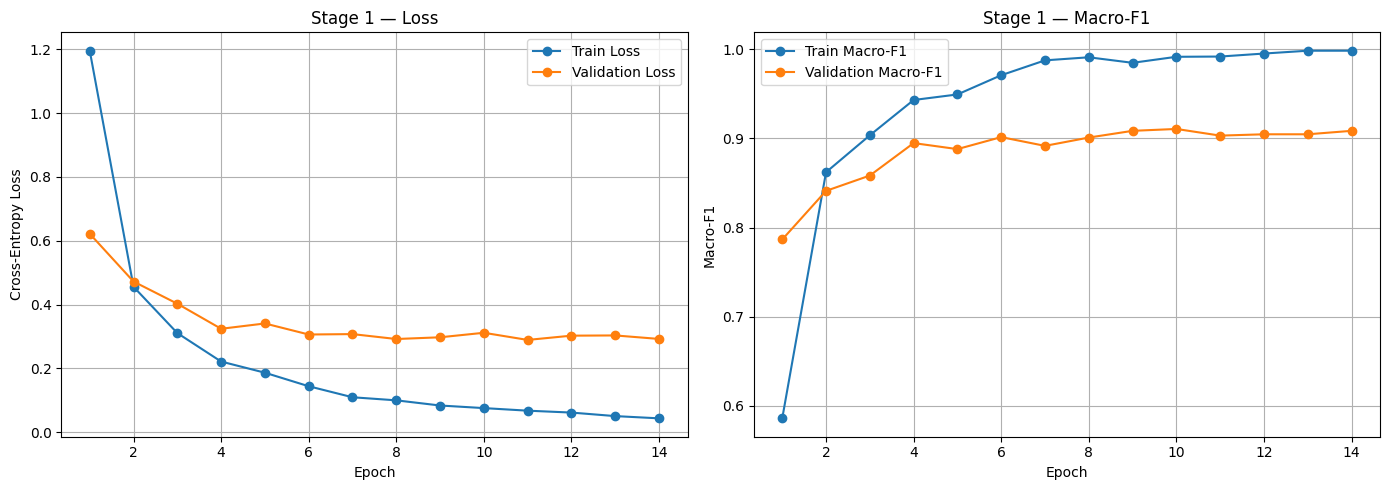

STAGE 1 BEST RESULT
Best epoch: 10
Validation Accuracy: 0.9161
Validation Macro-F1: 0.9106


In [ ]:
# ============================================================
# CELL 16 — STAGE 1 LEARNING CURVES
# ============================================================

epochs_ran = range(
    1,
    len(stage1_history["train_loss"]) + 1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)


# ============================================================
# LOSS
# ============================================================

axes[0].plot(
    epochs_ran,
    stage1_history["train_loss"],
    marker="o",
    label="Train Loss"
)

axes[0].plot(
    epochs_ran,
    stage1_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

axes[0].set_title(
    "Stage 1 — Loss"
)

axes[0].set_xlabel(
    "Epoch"
)

axes[0].set_ylabel(
    "Cross-Entropy Loss"
)

axes[0].legend()
axes[0].grid(True)


# ============================================================
# MACRO-F1
# ============================================================

axes[1].plot(
    epochs_ran,
    stage1_history["train_macro_f1"],
    marker="o",
    label="Train Macro-F1"
)

axes[1].plot(
    epochs_ran,
    stage1_history["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1"
)

axes[1].set_title(
    "Stage 1 — Macro-F1"
)

axes[1].set_xlabel(
    "Epoch"
)

axes[1].set_ylabel(
    "Macro-F1"
)

axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()


# ============================================================
# BEST VALIDATION RESULTS
# ============================================================

best_epoch = np.argmax(
    stage1_history["val_macro_f1"]
) + 1

best_val_f1 = max(
    stage1_history["val_macro_f1"]
)

best_val_acc = stage1_history[
    "val_accuracy"
][best_epoch - 1]

print("=" * 80)
print("STAGE 1 BEST RESULT")
print("=" * 80)

print("Best epoch:", best_epoch)
print(f"Validation Accuracy: {best_val_acc:.4f}")
print(f"Validation Macro-F1: {best_val_f1:.4f}")

STAGE 1 — VALIDATION CLASSIFICATION REPORT
                     precision    recall  f1-score   support

      gond painting     1.0000    1.0000    1.0000        15
  kalighat painting     1.0000    0.9459    0.9722        37
    kangra painting     0.9286    1.0000    0.9630        13
       kerala mural     1.0000    0.9286    0.9630        14
 madhubani painting     0.9231    0.8571    0.8889        14
mandana art drawing     0.7917    0.9048    0.8444        21
   pichwai painting     0.8125    0.8667    0.8387        15
     warli painting     0.8462    0.7857    0.8148        14

           accuracy                         0.9161       143
          macro avg     0.9127    0.9111    0.9106       143
       weighted avg     0.9207    0.9161    0.9170       143

STAGE 1 — VALIDATION SUMMARY
Accuracy          : 0.9161
Macro-F1          : 0.9106
Weighted-F1       : 0.9170
Balanced Accuracy : 0.9111


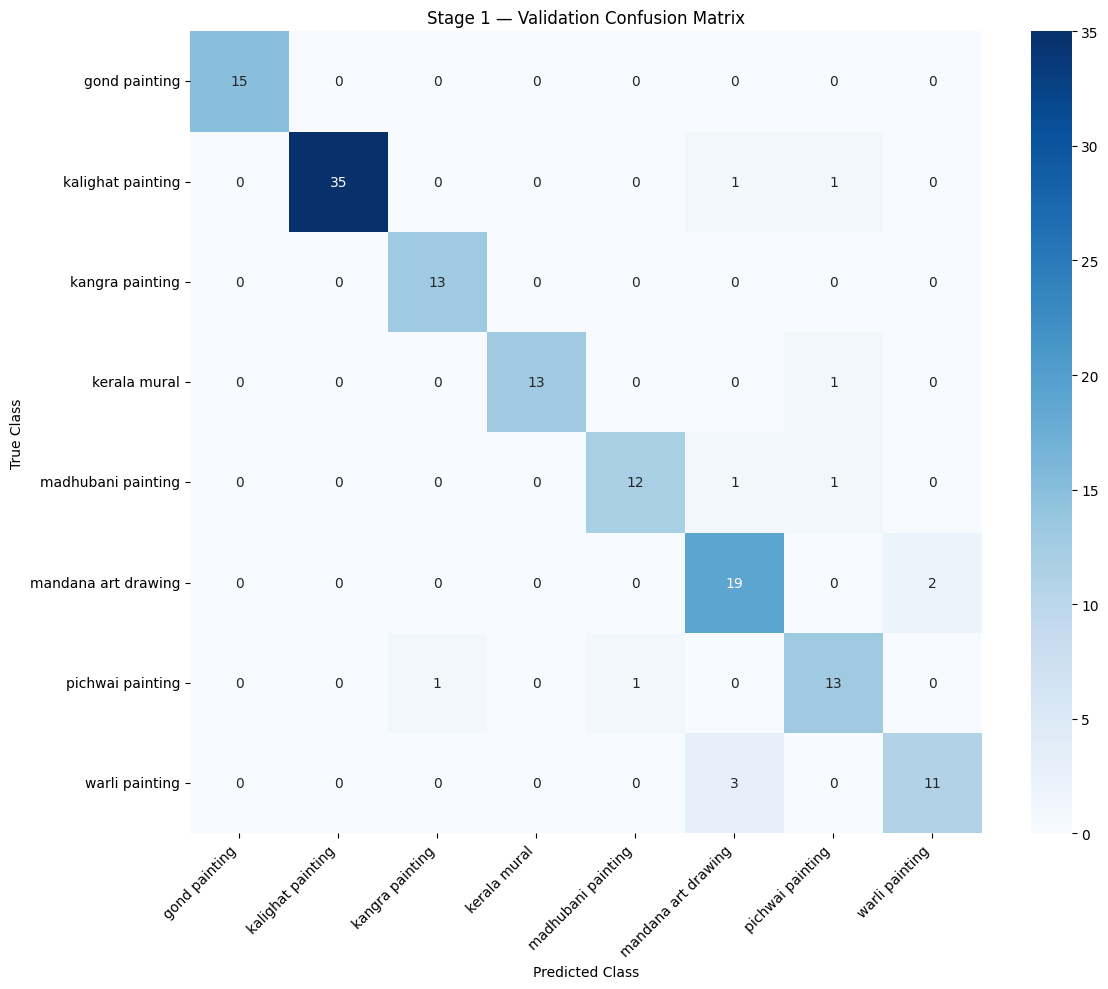

In [ ]:
# ============================================================
# CELL 17 — STAGE 1 DETAILED VALIDATION EVALUATION
# ============================================================

@torch.no_grad()
def get_predictions(
    model,
    loader,
    device
):

    model.eval()

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        logits = model(images)

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )


# ============================================================
# GET VALIDATION PREDICTIONS
# ============================================================

val_labels, val_predictions = get_predictions(
    stage1_model,
    val_loader,
    device
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("=" * 80)
print("STAGE 1 — VALIDATION CLASSIFICATION REPORT")
print("=" * 80)

print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# SUMMARY METRICS
# ============================================================

val_accuracy = accuracy_score(
    val_labels,
    val_predictions
)

val_macro_f1 = f1_score(
    val_labels,
    val_predictions,
    average="macro"
)

val_weighted_f1 = f1_score(
    val_labels,
    val_predictions,
    average="weighted"
)

val_balanced_accuracy = balanced_accuracy_score(
    val_labels,
    val_predictions
)

print("=" * 80)
print("STAGE 1 — VALIDATION SUMMARY")
print("=" * 80)

print(f"Accuracy          : {val_accuracy:.4f}")
print(f"Macro-F1          : {val_macro_f1:.4f}")
print(f"Weighted-F1       : {val_weighted_f1:.4f}")
print(f"Balanced Accuracy : {val_balanced_accuracy:.4f}")


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    val_labels,
    val_predictions
)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Stage 1 — Validation Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 18 — STAGE 2
# FROZEN DINOv2 + MLP CLASSIFIER
# ============================================================

class DINOv2MLPClassifier(nn.Module):

    def __init__(
        self,
        backbone,
        embedding_dim,
        num_classes,
        hidden_dim=512,
        projection_dim=256,
        dropout=0.30
    ):
        super().__init__()

        self.backbone = backbone

        # Keep DINOv2 frozen
        for param in self.backbone.parameters():
            param.requires_grad = False

        # MLP classification head
        self.classifier = nn.Sequential(

            nn.Linear(
                embedding_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                projection_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                projection_dim,
                num_classes
            )
        )


    def forward(self, x):

        # Frozen feature extraction
        with torch.no_grad():
            features = self.backbone(x)

        logits = self.classifier(features)

        return logits


# ============================================================
# CREATE STAGE 2 MODEL
# ============================================================

stage2_model = DINOv2MLPClassifier(
    backbone=dinov2,
    embedding_dim=EMBEDDING_DIM,
    num_classes=num_classes,
    hidden_dim=512,
    projection_dim=256,
    dropout=0.30
).to(device)


# ============================================================
# LOSS
# ============================================================

stage2_criterion = nn.CrossEntropyLoss()


# ============================================================
# OPTIMIZER
# ============================================================

stage2_optimizer = torch.optim.AdamW(
    stage2_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ============================================================
# PARAMETER SUMMARY
# ============================================================

stage2_total_params = sum(
    p.numel()
    for p in stage2_model.parameters()
)

stage2_trainable_params = sum(
    p.numel()
    for p in stage2_model.parameters()
    if p.requires_grad
)

print("=" * 80)
print("STAGE 2 — FROZEN DINOv2 + MLP CLASSIFIER")
print("=" * 80)

print("Embedding dimension :", EMBEDDING_DIM)
print("Hidden dimension    :", 512)
print("MLP dimension       :", 256)
print("Dropout             :", 0.30)

print(f"\nTotal parameters:     {stage2_total_params:,}")
print(f"Trainable parameters: {stage2_trainable_params:,}")

print("\nDINOv2 frozen: ✓")
print("MLP classifier trainable: ✓")

STAGE 2 — FROZEN DINOv2 + MLP CLASSIFIER
Embedding dimension : 768
Hidden dimension    : 512
MLP dimension       : 256
Dropout             : 0.3

Total parameters:     87,107,592
Trainable parameters: 527,112

DINOv2 frozen: ✓
MLP classifier trainable: ✓


In [ ]:
# ============================================================
# CELL 19 — TRAIN STAGE 2
# FROZEN DINOv2 + MLP CLASSIFIER
# ============================================================

STAGE2_EPOCHS = 15
STAGE2_PATIENCE = 4

print("=" * 80)
print("STAGE 2 — FROZEN DINOv2 + MLP CLASSIFIER")
print("=" * 80)

stage2_model, stage2_history = fit_model(
    model=stage2_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=stage2_criterion,
    optimizer=stage2_optimizer,
    device=device,
    epochs=STAGE2_EPOCHS,
    patience=STAGE2_PATIENCE
)

print("\nStage 2 training complete.")

STAGE 2 — FROZEN DINOv2 + MLP CLASSIFIER


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15 | Train Loss: 1.1000 | Train Acc: 0.6466 | Train F1: 0.6184 | Val Loss: 0.4458 | Val Acc: 0.8531 | Val F1: 0.8406


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/15 | Train Loss: 0.3685 | Train Acc: 0.8602 | Train F1: 0.8465 | Val Loss: 0.4250 | Val Acc: 0.8671 | Val F1: 0.8605


...

Epoch 06/15 | Train Loss: 0.0658 | Train Acc: 0.9759 | Train F1: 0.9723 | Val Loss: 0.5114 | Val Acc: 0.8392 | Val F1: 0.8335


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 07/15 | Train Loss: 0.0758 | Train Acc: 0.9805 | Train F1: 0.9807 | Val Loss: 0.5333 | Val Acc: 0.8462 | Val F1: 0.8424


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 08/15 | Train Loss: 0.0606 | Train Acc: 0.9729 | Train F1: 0.9703 | Val Loss: 0.4837 | Val Acc: 0.8881 | Val F1: 0.8781

Early stopping triggered after 8 epochs.

Best validation Macro-F1: 0.9054

Stage 2 training complete.


STAGE 1 vs STAGE 2


,Stage,Best Epoch,Validation Accuracy,Validation Macro-F1,Validation Loss
0,Stage 1 — Linear,10,0.9161,0.9106,0.3115
1,Stage 2 — MLP,4,0.9091,0.9054,0.3128



STAGE 2 IMPROVEMENT
Accuracy change : -0.0070
Macro-F1 change : -0.0053


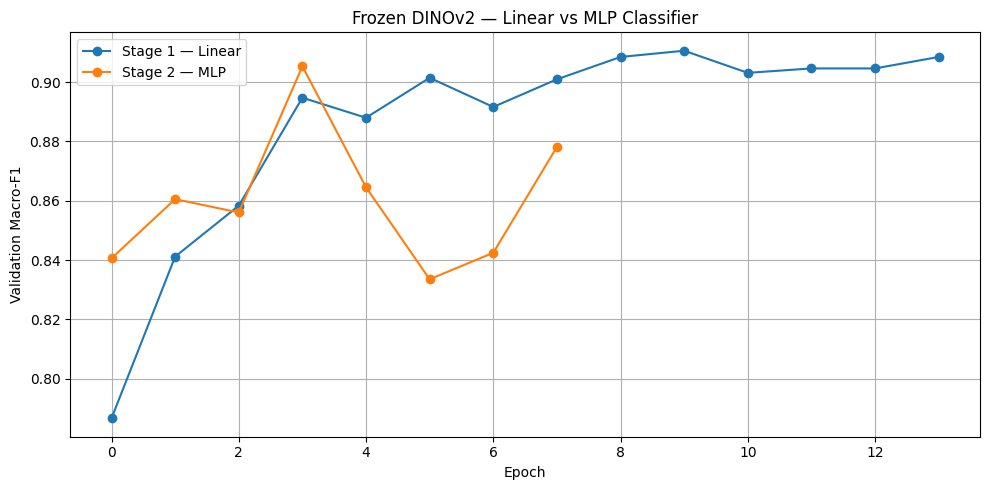

In [ ]:
# ============================================================
# CELL 20 — STAGE 1 vs STAGE 2 COMPARISON
# ============================================================

def get_best_result(history):

    best_idx = np.argmax(
        history["val_macro_f1"]
    )

    return {
        "Best Epoch": best_idx + 1,
        "Validation Accuracy": history["val_accuracy"][best_idx],
        "Validation Macro-F1": history["val_macro_f1"][best_idx],
        "Validation Loss": history["val_loss"][best_idx]
    }


stage1_result = get_best_result(
    stage1_history
)

stage2_result = get_best_result(
    stage2_history
)


comparison_df = pd.DataFrame(
    [
        {
            "Stage": "Stage 1 — Linear",
            **stage1_result
        },
        {
            "Stage": "Stage 2 — MLP",
            **stage2_result
        }
    ]
)

print("=" * 80)
print("STAGE 1 vs STAGE 2")
print("=" * 80)

display(
    comparison_df.style.format({
        "Validation Accuracy": "{:.4f}",
        "Validation Macro-F1": "{:.4f}",
        "Validation Loss": "{:.4f}"
    })
)


# ============================================================
# IMPROVEMENT
# ============================================================

accuracy_change = (
    stage2_result["Validation Accuracy"]
    - stage1_result["Validation Accuracy"]
)

f1_change = (
    stage2_result["Validation Macro-F1"]
    - stage1_result["Validation Macro-F1"]
)

print("\n" + "=" * 80)
print("STAGE 2 IMPROVEMENT")
print("=" * 80)

print(
    f"Accuracy change : {accuracy_change:+.4f}"
)

print(
    f"Macro-F1 change : {f1_change:+.4f}"
)


# ============================================================
# LEARNING CURVES
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    stage1_history["val_macro_f1"],
    marker="o",
    label="Stage 1 — Linear"
)

plt.plot(
    stage2_history["val_macro_f1"],
    marker="o",
    label="Stage 2 — MLP"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1")

plt.title(
    "Frozen DINOv2 — Linear vs MLP Classifier"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 21 — SUPERVISED CONTRASTIVE LEARNING MODEL
# ============================================================

class DINOv2SupConModel(nn.Module):

    def __init__(
        self,
        backbone,
        embedding_dim,
        num_classes,
        projection_dim=256,
        hidden_dim=512,
        dropout=0.30
    ):
        super().__init__()

        self.backbone = backbone

        # ----------------------------------------------------
        # Backbone is initially frozen
        # ----------------------------------------------------
        for param in self.backbone.parameters():
            param.requires_grad = False

        # ----------------------------------------------------
        # Classification head
        # ----------------------------------------------------
        self.classifier = nn.Sequential(
            nn.Linear(
                embedding_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                num_classes
            )
        )

        # ----------------------------------------------------
        # Projection head
        #
        # Used ONLY for contrastive learning
        # ----------------------------------------------------
        self.projector = nn.Sequential(
            nn.Linear(
                embedding_dim,
                hidden_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                hidden_dim,
                projection_dim
            )
        )


    def extract_features(self, x):

        features = self.backbone(x)

        return features


    def forward(self, x):

        features = self.extract_features(x)

        logits = self.classifier(features)

        projection = self.projector(features)

        # Normalize embedding for cosine similarity
        projection = F.normalize(
            projection,
            p=2,
            dim=1
        )

        return logits, projection


# ============================================================
# CREATE MODEL
# ============================================================

stage3_model = DINOv2SupConModel(
    backbone=dinov2,
    embedding_dim=EMBEDDING_DIM,
    num_classes=num_classes,
    projection_dim=256,
    hidden_dim=512,
    dropout=0.30
).to(device)


# ============================================================
# PARAMETER SUMMARY
# ============================================================

stage3_total_params = sum(
    p.numel()
    for p in stage3_model.parameters()
)

stage3_trainable_params = sum(
    p.numel()
    for p in stage3_model.parameters()
    if p.requires_grad
)

print("=" * 80)
print("STAGE 3 — DINOv2 + SUPERVISED CONTRASTIVE LEARNING")
print("=" * 80)

print("Backbone             : DINOv2 ViT-B/14")
print("Input embedding      :", EMBEDDING_DIM)
print("Classifier hidden    : 512")
print("Projection dimension : 256")
print("Dropout              : 0.30")

print(f"\nTotal parameters:     {stage3_total_params:,}")
print(f"Trainable parameters: {stage3_trainable_params:,}")

print("\nDINOv2 frozen: ✓")
print("Classification head: ✓")
print("Projection head: ✓")

STAGE 3 — DINOv2 + SUPERVISED CONTRASTIVE LEARNING
Backbone             : DINOv2 ViT-B/14
Input embedding      : 768
Classifier hidden    : 512
Projection dimension : 256
Dropout              : 0.30

Total parameters:     87,503,368
Trainable parameters: 922,888

DINOv2 frozen: ✓
Classification head: ✓
Projection head: ✓


In [ ]:
# ============================================================
# CELL 22 — SUPERVISED CONTRASTIVE LOSS
# ============================================================

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss

    Features:
        [batch_size, n_views, embedding_dim]

    Labels:
        [batch_size]

    Same-class samples are treated as positive pairs.
    Different-class samples are treated as negatives.
    """

    def __init__(
        self,
        temperature=0.07
    ):
        super().__init__()

        self.temperature = temperature


    def forward(
        self,
        features,
        labels
    ):

        device = features.device

        # ----------------------------------------------------
        # Validate dimensions
        # ----------------------------------------------------

        if features.dim() != 3:
            raise ValueError(
                "features must have shape "
                "[batch_size, n_views, embedding_dim]"
            )

        batch_size = features.shape[0]
        n_views = features.shape[1]

        # ----------------------------------------------------
        # Flatten views
        #
        # [B, V, D]
        #       ↓
        # [B*V, D]
        # ----------------------------------------------------

        features = features.view(
            batch_size * n_views,
            -1
        )

        # ----------------------------------------------------
        # Normalize embeddings
        # ----------------------------------------------------

        features = F.normalize(
            features,
            p=2,
            dim=1
        )

        # ----------------------------------------------------
        # Similarity matrix
        # ----------------------------------------------------

        similarity = torch.matmul(
            features,
            features.T
        ) / self.temperature

        # ----------------------------------------------------
        # Numerical stability
        # ----------------------------------------------------

        logits_max, _ = torch.max(
            similarity,
            dim=1,
            keepdim=True
        )

        logits = similarity - logits_max.detach()

        # ----------------------------------------------------
        # Repeat labels for every view
        # ----------------------------------------------------

        labels = labels.contiguous().view(-1, 1)

        labels = labels.repeat(
            n_views,
            1
        )

        # ----------------------------------------------------
        # Positive mask
        #
        # Same class = positive
        # ----------------------------------------------------

        mask = torch.eq(
            labels,
            labels.T
        ).float().to(device)

        # ----------------------------------------------------
        # Remove self-comparisons
        # ----------------------------------------------------

        logits_mask = torch.ones_like(mask)

        logits_mask.fill_diagonal_(0)

        mask = mask * logits_mask

        # ----------------------------------------------------
        # Log probability
        # ----------------------------------------------------

        exp_logits = (
            torch.exp(logits)
            * logits_mask
        )

        log_prob = (
            logits
            - torch.log(
                exp_logits.sum(
                    dim=1,
                    keepdim=True
                ) + 1e-12
            )
        )

        # ----------------------------------------------------
        # Mean log probability over positives
        # ----------------------------------------------------

        positive_count = mask.sum(
            dim=1
        )

        # Prevent division by zero
        positive_count = torch.clamp(
            positive_count,
            min=1.0
        )

        mean_log_prob_pos = (
            (mask * log_prob).sum(dim=1)
            / positive_count
        )

        # ----------------------------------------------------
        # Final loss
        # ----------------------------------------------------

        loss = -mean_log_prob_pos.mean()

        return loss


# ============================================================
# CREATE LOSS
# ============================================================

supcon_criterion = SupConLoss(
    temperature=0.07
)

print("=" * 80)
print("SUPERVISED CONTRASTIVE LOSS")
print("=" * 80)

print("Temperature:", supcon_criterion.temperature)
print("Loss initialized successfully.")

SUPERVISED CONTRASTIVE LOSS
Temperature: 0.07
Loss initialized successfully.


In [ ]:
# ============================================================
# CELL 23 — COMBINED CE + SUPCON TRAINING
# ============================================================

def train_supcon_one_epoch(
    model,
    loader,
    ce_criterion,
    supcon_criterion,
    optimizer,
    device,
    ce_weight=1.0,
    supcon_weight=0.1
):
    """
    Train one epoch using:

        Total Loss = CE + beta * SupCon
    """

    model.train()

    # Backbone is still frozen during Stage 3
    model.backbone.eval()

    running_total_loss = 0.0
    running_ce_loss = 0.0
    running_supcon_loss = 0.0

    all_predictions = []
    all_labels = []

    for view_1, view_2, labels in loader:

        view_1 = view_1.to(
            device,
            non_blocking=True
        )

        view_2 = view_2.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # ----------------------------------------------------
        # Forward pass for both views
        # ----------------------------------------------------

        logits_1, projection_1 = model(view_1)

        logits_2, projection_2 = model(view_2)

        # ----------------------------------------------------
        # Classification loss
        #
        # Both augmented views contribute to CE
        # ----------------------------------------------------

        ce_loss_1 = ce_criterion(
            logits_1,
            labels
        )

        ce_loss_2 = ce_criterion(
            logits_2,
            labels
        )

        ce_loss = (
            ce_loss_1 + ce_loss_2
        ) / 2.0

        # ----------------------------------------------------
        # Contrastive features
        #
        # [B, 2, D]
        # ----------------------------------------------------

        features = torch.stack(
            [
                projection_1,
                projection_2
            ],
            dim=1
        )

        supcon_loss = supcon_criterion(
            features,
            labels
        )

        # ----------------------------------------------------
        # Combined objective
        # ----------------------------------------------------

        total_loss = (
            ce_weight * ce_loss
            + supcon_weight * supcon_loss
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        total_loss.backward()

        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        batch_size = labels.size(0)

        running_total_loss += (
            total_loss.item()
            * batch_size
        )

        running_ce_loss += (
            ce_loss.item()
            * batch_size
        )

        running_supcon_loss += (
            supcon_loss.item()
            * batch_size
        )

        # Average predictions from both views
        avg_logits = (
            logits_1 + logits_2
        ) / 2.0

        predictions = torch.argmax(
            avg_logits,
            dim=1
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

    dataset_size = len(loader.dataset)

    epoch_total_loss = (
        running_total_loss / dataset_size
    )

    epoch_ce_loss = (
        running_ce_loss / dataset_size
    )

    epoch_supcon_loss = (
        running_supcon_loss / dataset_size
    )

    epoch_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    epoch_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return {
        "total_loss": epoch_total_loss,
        "ce_loss": epoch_ce_loss,
        "supcon_loss": epoch_supcon_loss,
        "accuracy": epoch_accuracy,
        "macro_f1": epoch_macro_f1
    }


# ============================================================
# VALIDATION FOR SUPCON MODEL
# ============================================================

@torch.no_grad()
def validate_supcon_model(
    model,
    loader,
    ce_criterion,
    device
):
    """
    Validation uses ONE deterministic image view.

    SupCon loss is NOT used for model selection during validation.
    We evaluate classification performance using CE.
    """

    model.eval()

    running_loss = 0.0

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        logits, _ = model(images)

        loss = ce_criterion(
            logits,
            labels
        )

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

    val_loss = (
        running_loss
        / len(loader.dataset)
    )

    val_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    val_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        val_loss,
        val_accuracy,
        val_macro_f1
    )


# ============================================================
# FULL SUPCON TRAINING LOOP
# ============================================================

def fit_supcon_model(
    model,
    train_loader,
    val_loader,
    ce_criterion,
    supcon_criterion,
    optimizer,
    device,
    epochs=15,
    patience=4,
    ce_weight=1.0,
    supcon_weight=0.1
):

    history = {
        "train_total_loss": [],
        "train_ce_loss": [],
        "train_supcon_loss": [],
        "train_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    best_val_f1 = -float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):

        train_metrics = train_supcon_one_epoch(
            model=model,
            loader=train_loader,
            ce_criterion=ce_criterion,
            supcon_criterion=supcon_criterion,
            optimizer=optimizer,
            device=device,
            ce_weight=ce_weight,
            supcon_weight=supcon_weight
        )

        (
            val_loss,
            val_accuracy,
            val_macro_f1
        ) = validate_supcon_model(
            model=model,
            loader=val_loader,
            ce_criterion=ce_criterion,
            device=device
        )

        # ----------------------------------------------------
        # Store metrics
        # ----------------------------------------------------

        history["train_total_loss"].append(
            train_metrics["total_loss"]
        )

        history["train_ce_loss"].append(
            train_metrics["ce_loss"]
        )

        history["train_supcon_loss"].append(
            train_metrics["supcon_loss"]
        )

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["train_macro_f1"].append(
            train_metrics["macro_f1"]
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        history["val_macro_f1"].append(
            val_macro_f1
        )

        # ----------------------------------------------------
        # Print epoch results
        # ----------------------------------------------------

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Total: {train_metrics['total_loss']:.4f} | "
            f"CE: {train_metrics['ce_loss']:.4f} | "
            f"SupCon: {train_metrics['supcon_loss']:.4f} | "
            f"Train F1: {train_metrics['macro_f1']:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val F1: {val_macro_f1:.4f}"
        )

        # ----------------------------------------------------
        # Save best model based on validation Macro-F1
        # ----------------------------------------------------

        if val_macro_f1 > best_val_f1:

            best_val_f1 = val_macro_f1

            best_state = deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if patience_counter >= patience:

            print(
                f"\nEarly stopping triggered "
                f"after {epoch + 1} epochs."
            )

            break

    # --------------------------------------------------------
    # Restore best model
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    print(
        f"\nBest validation Macro-F1: "
        f"{best_val_f1:.4f}"
    )

    return model, history

In [ ]:
# ============================================================
# CELL 24 — TRAIN STAGE 3
# FROZEN DINOv2 + CE + SUPERVISED CONTRASTIVE LOSS
# ============================================================

STAGE3_EPOCHS = 20
STAGE3_PATIENCE = 5

CE_WEIGHT = 1.0
SUPCON_WEIGHT = 0.10

STAGE3_LR = 1e-3
STAGE3_WEIGHT_DECAY = 1e-4


# ============================================================
# OPTIMIZER
# Only classifier + projection head are trainable
# ============================================================

stage3_optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        stage3_model.parameters()
    ),
    lr=STAGE3_LR,
    weight_decay=STAGE3_WEIGHT_DECAY
)


# ============================================================
# VERIFY TRAINABLE PARAMETERS
# ============================================================

trainable_params = sum(
    p.numel()
    for p in stage3_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in stage3_model.parameters()
)

print("=" * 80)
print("STAGE 3 — FROZEN DINOv2 + SUPCON")
print("=" * 80)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

print("\nConfiguration:")
print("CE weight            :", CE_WEIGHT)
print("SupCon weight        :", SUPCON_WEIGHT)
print("Temperature          :", supcon_criterion.temperature)
print("Learning rate        :", STAGE3_LR)
print("Weight decay         :", STAGE3_WEIGHT_DECAY)
print("Epochs               :", STAGE3_EPOCHS)
print("Early stopping       :", STAGE3_PATIENCE)


# ============================================================
# TRAIN
# ============================================================

stage3_model, stage3_history = fit_supcon_model(
    model=stage3_model,
    train_loader=contrastive_train_loader,
    val_loader=val_loader,
    ce_criterion=stage3_criterion if "stage3_criterion" in globals()
                 else nn.CrossEntropyLoss(),
    supcon_criterion=supcon_criterion,
    optimizer=stage3_optimizer,
    device=device,
    epochs=STAGE3_EPOCHS,
    patience=STAGE3_PATIENCE,
    ce_weight=CE_WEIGHT,
    supcon_weight=SUPCON_WEIGHT
)

print("\nStage 3 training complete.")

STAGE 3 — FROZEN DINOv2 + SUPCON
Total parameters     : 87,503,368
Trainable parameters : 922,888

Configuration:
CE weight            : 1.0
SupCon weight        : 0.1
Temperature          : 0.07
Learning rate        : 0.001
Weight decay         : 0.0001
Epochs               : 20
Early stopping       : 5


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/20 | Total: 1.0808 | CE: 0.6684 | SupCon: 4.1239 | Train F1: 0.7982 | Val Acc: 0.7972 | Val F1: 0.7913


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/20 | Total: 0.6075 | CE: 0.2086 | SupCon: 3.9897 | Train F1: 0.9435 | Val Acc: 0.8601 | Val F1: 0.8511


...

Epoch 08/20 | Total: 0.4319 | CE: 0.0332 | SupCon: 3.9874 | Train F1: 0.9937 | Val Acc: 0.8741 | Val F1: 0.8703


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 09/20 | Total: 0.4166 | CE: 0.0177 | SupCon: 3.9888 | Train F1: 0.9984 | Val Acc: 0.8881 | Val F1: 0.8751


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 10/20 | Total: 0.4113 | CE: 0.0124 | SupCon: 3.9888 | Train F1: 0.9984 | Val Acc: 0.8741 | Val F1: 0.8701

Early stopping triggered after 10 epochs.

Best validation Macro-F1: 0.9068

Stage 3 training complete.


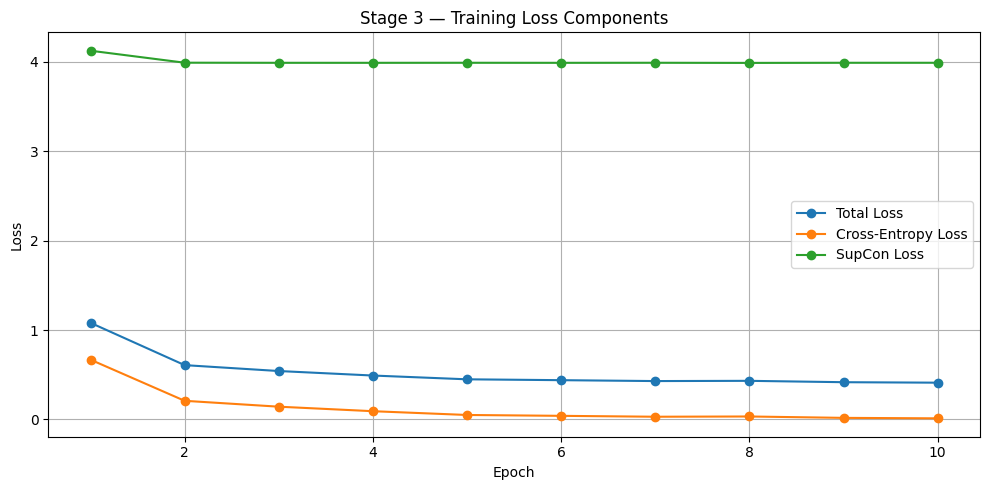

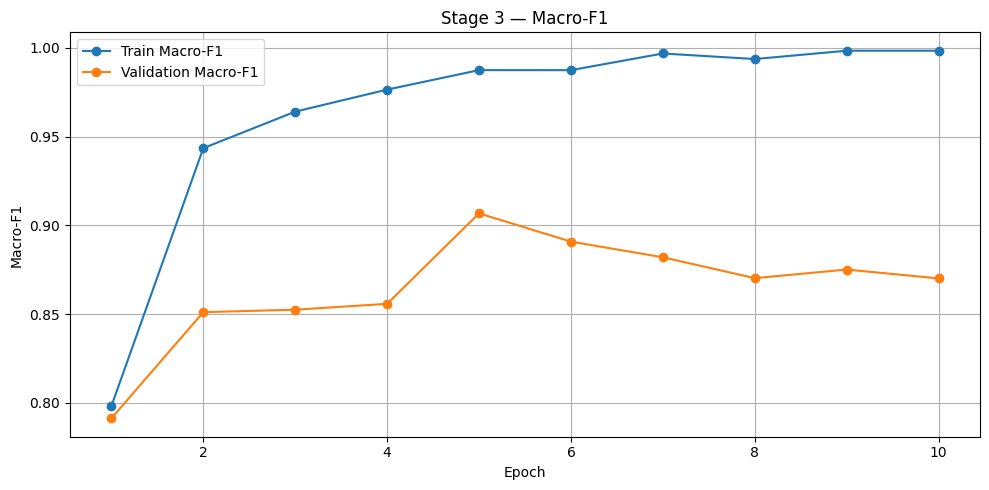

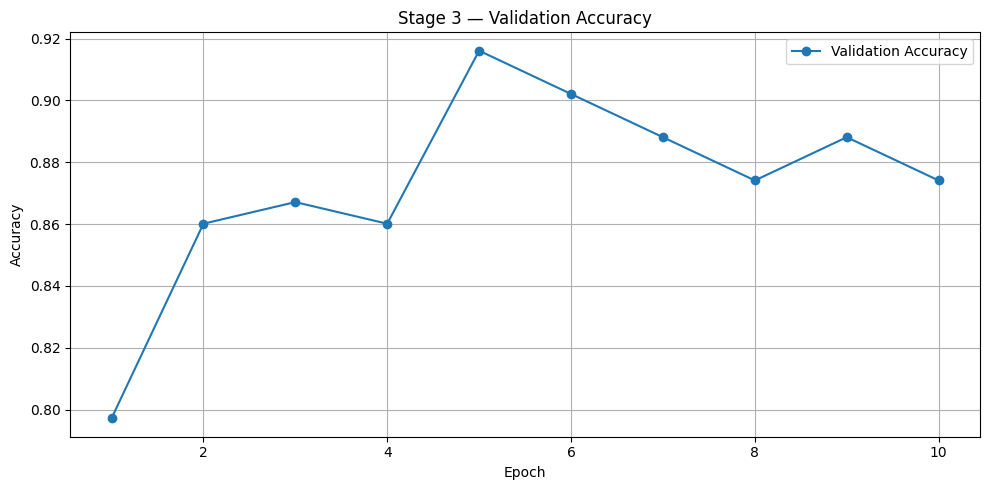

STAGE 3 BEST RESULT
Best epoch: 5
Validation Accuracy: 0.9161
Validation Macro-F1: 0.9068
Training CE Loss: 0.0500
Training SupCon Loss: 3.9889


In [ ]:
# ============================================================
# CELL 25 — STAGE 3 TRAINING ANALYSIS
# ============================================================

epochs_ran = range(
    1,
    len(stage3_history["train_total_loss"]) + 1
)


# ============================================================
# PLOT 1 — LOSS COMPONENTS
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_ran,
    stage3_history["train_total_loss"],
    marker="o",
    label="Total Loss"
)

plt.plot(
    epochs_ran,
    stage3_history["train_ce_loss"],
    marker="o",
    label="Cross-Entropy Loss"
)

plt.plot(
    epochs_ran,
    stage3_history["train_supcon_loss"],
    marker="o",
    label="SupCon Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Stage 3 — Training Loss Components"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2 — VALIDATION PERFORMANCE
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_ran,
    stage3_history["train_macro_f1"],
    marker="o",
    label="Train Macro-F1"
)

plt.plot(
    epochs_ran,
    stage3_history["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "Stage 3 — Macro-F1"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3 — VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_ran,
    stage3_history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Stage 3 — Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# BEST RESULT
# ============================================================

best_idx = np.argmax(
    stage3_history["val_macro_f1"]
)

best_stage3_f1 = (
    stage3_history["val_macro_f1"][best_idx]
)

best_stage3_accuracy = (
    stage3_history["val_accuracy"][best_idx]
)

best_stage3_epoch = best_idx + 1


print("=" * 80)
print("STAGE 3 BEST RESULT")
print("=" * 80)

print("Best epoch:", best_stage3_epoch)

print(
    f"Validation Accuracy: "
    f"{best_stage3_accuracy:.4f}"
)

print(
    f"Validation Macro-F1: "
    f"{best_stage3_f1:.4f}"
)

print(
    f"Training CE Loss: "
    f"{stage3_history['train_ce_loss'][best_idx]:.4f}"
)

print(
    f"Training SupCon Loss: "
    f"{stage3_history['train_supcon_loss'][best_idx]:.4f}"
)

DINOv2 STAGE COMPARISON


,Stage,Backbone,Metric Learning,Best Epoch,Validation Accuracy,Validation Macro-F1
0,Stage 1 — Linear,Frozen DINOv2,No,10,0.9161,0.9106
1,Stage 2 — MLP,Frozen DINOv2,No,4,0.9091,0.9054
2,Stage 3 — SupCon,Frozen DINOv2,Yes,5,0.9161,0.9068



IMPROVEMENT OVER STAGE 1
Stage 2 Accuracy change : -0.0070
Stage 2 Macro-F1 change : -0.0053
Stage 3 Accuracy change : +0.0000
Stage 3 Macro-F1 change : -0.0038


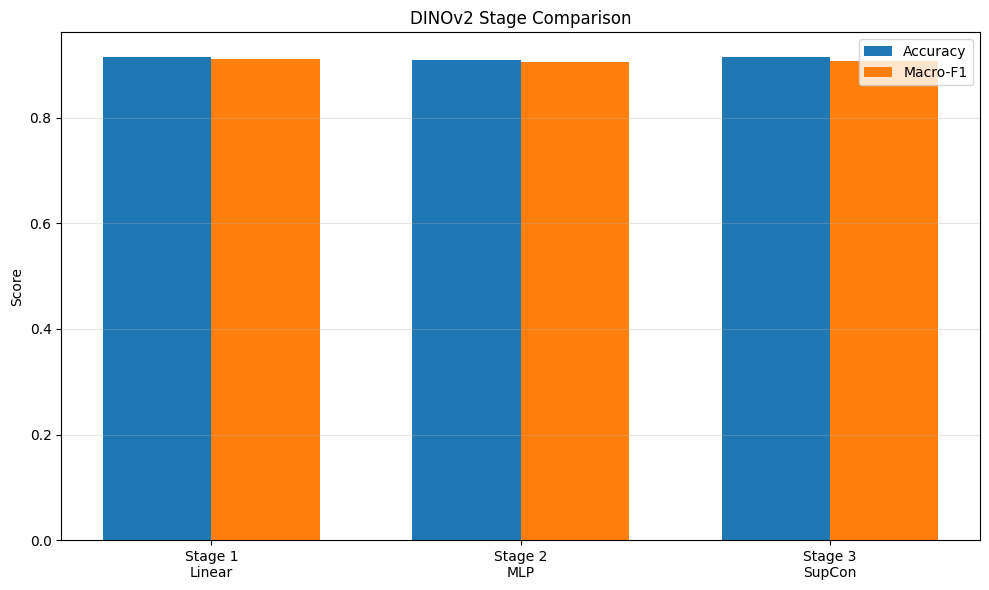

In [ ]:
# ============================================================
# CELL 26 — STAGE 1 vs STAGE 2 vs STAGE 3
# ============================================================

def get_best_history_result(
    history,
    accuracy_key="val_accuracy",
    f1_key="val_macro_f1"
):

    best_idx = np.argmax(
        history[f1_key]
    )

    return {
        "Best Epoch": best_idx + 1,
        "Validation Accuracy": history[accuracy_key][best_idx],
        "Validation Macro-F1": history[f1_key][best_idx]
    }


# ============================================================
# COLLECT RESULTS
# ============================================================

stage1_result = get_best_history_result(
    stage1_history
)

stage2_result = get_best_history_result(
    stage2_history
)

stage3_result = get_best_history_result(
    stage3_history
)


# ============================================================
# COMPARISON TABLE
# ============================================================

pipeline_comparison = pd.DataFrame([
    {
        "Stage": "Stage 1 — Linear",
        "Backbone": "Frozen DINOv2",
        "Metric Learning": "No",
        **stage1_result
    },

    {
        "Stage": "Stage 2 — MLP",
        "Backbone": "Frozen DINOv2",
        "Metric Learning": "No",
        **stage2_result
    },

    {
        "Stage": "Stage 3 — SupCon",
        "Backbone": "Frozen DINOv2",
        "Metric Learning": "Yes",
        **stage3_result
    }
])


print("=" * 100)
print("DINOv2 STAGE COMPARISON")
print("=" * 100)

display(
    pipeline_comparison.style.format({
        "Validation Accuracy": "{:.4f}",
        "Validation Macro-F1": "{:.4f}"
    })
)


# ============================================================
# IMPROVEMENTS OVER STAGE 1
# ============================================================

print("\n" + "=" * 100)
print("IMPROVEMENT OVER STAGE 1")
print("=" * 100)

stage2_acc_delta = (
    stage2_result["Validation Accuracy"]
    - stage1_result["Validation Accuracy"]
)

stage2_f1_delta = (
    stage2_result["Validation Macro-F1"]
    - stage1_result["Validation Macro-F1"]
)

stage3_acc_delta = (
    stage3_result["Validation Accuracy"]
    - stage1_result["Validation Accuracy"]
)

stage3_f1_delta = (
    stage3_result["Validation Macro-F1"]
    - stage1_result["Validation Macro-F1"]
)

print(
    f"Stage 2 Accuracy change : "
    f"{stage2_acc_delta:+.4f}"
)

print(
    f"Stage 2 Macro-F1 change : "
    f"{stage2_f1_delta:+.4f}"
)

print(
    f"Stage 3 Accuracy change : "
    f"{stage3_acc_delta:+.4f}"
)

print(
    f"Stage 3 Macro-F1 change : "
    f"{stage3_f1_delta:+.4f}"
)


# ============================================================
# VISUAL COMPARISON
# ============================================================

stage_names = [
    "Stage 1\nLinear",
    "Stage 2\nMLP",
    "Stage 3\nSupCon"
]

accuracy_values = [
    stage1_result["Validation Accuracy"],
    stage2_result["Validation Accuracy"],
    stage3_result["Validation Accuracy"]
]

f1_values = [
    stage1_result["Validation Macro-F1"],
    stage2_result["Validation Macro-F1"],
    stage3_result["Validation Macro-F1"]
]


x = np.arange(
    len(stage_names)
)

width = 0.35

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    x - width / 2,
    accuracy_values,
    width,
    label="Accuracy"
)

ax.bar(
    x + width / 2,
    f1_values,
    width,
    label="Macro-F1"
)

ax.set_ylabel("Score")
ax.set_title(
    "DINOv2 Stage Comparison"
)

ax.set_xticks(x)
ax.set_xticklabels(stage_names)

ax.legend()
ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 27 — EXTRACT STAGE 3 EMBEDDINGS
# ============================================================

@torch.no_grad()
def extract_embeddings(
    model,
    loader,
    device,
    use_projection=False
):
    """
    Extract embeddings and labels.

    use_projection=False:
        Extract DINOv2 backbone features.

    use_projection=True:
        Extract normalized SupCon projection embeddings.
    """

    model.eval()

    all_embeddings = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Extract backbone features
        # ----------------------------------------------------

        features = model.backbone(images)

        if use_projection:

            embeddings = model.projector(
                features
            )

            embeddings = F.normalize(
                embeddings,
                p=2,
                dim=1
            )

        else:

            embeddings = features

        all_embeddings.append(
            embeddings.cpu()
        )

        all_labels.append(
            labels
        )

    embeddings = torch.cat(
        all_embeddings,
        dim=0
    ).numpy()

    labels = torch.cat(
        all_labels,
        dim=0
    ).numpy()

    return embeddings, labels


# ============================================================
# EXTRACT BACKBONE FEATURES
# ============================================================

stage3_backbone_embeddings, stage3_labels = (
    extract_embeddings(
        stage3_model,
        val_loader,
        device,
        use_projection=False
    )
)


# ============================================================
# EXTRACT SUPCON PROJECTION EMBEDDINGS
# ============================================================

stage3_projection_embeddings, stage3_projection_labels = (
    extract_embeddings(
        stage3_model,
        val_loader,
        device,
        use_projection=True
    )
)


# ============================================================
# VERIFY
# ============================================================

print("=" * 80)
print("STAGE 3 EMBEDDING EXTRACTION")
print("=" * 80)

print(
    "Backbone embedding shape   :",
    stage3_backbone_embeddings.shape
)

print(
    "Projection embedding shape :",
    stage3_projection_embeddings.shape
)

print(
    "Labels shape               :",
    stage3_labels.shape
)

print("\nExpected dimensions:")
print("DINOv2 backbone :", EMBEDDING_DIM)
print("SupCon projection: 256")

STAGE 3 EMBEDDING EXTRACTION
Backbone embedding shape   : (143, 768)
Projection embedding shape : (143, 256)
Labels shape               : (143,)

Expected dimensions:
DINOv2 backbone : 768
SupCon projection: 256


In [ ]:
# ============================================================
# CELL 28 — QUANTITATIVE EMBEDDING ANALYSIS
# ============================================================

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)
from sklearn.metrics import pairwise_distances


# ============================================================
# FUNCTION: EMBEDDING SEPARATION METRICS
# ============================================================

def calculate_embedding_metrics(
    embeddings,
    labels
):
    """
    Calculate quantitative class-separation metrics.
    """

    # --------------------------------------------------------
    # Pairwise Euclidean distances
    # --------------------------------------------------------

    distances = pairwise_distances(
        embeddings,
        metric="euclidean"
    )

    unique_classes = np.unique(labels)

    intra_class_distances = []
    inter_class_distances = []

    # --------------------------------------------------------
    # Calculate intra/inter class distances
    # --------------------------------------------------------

    for i, class_a in enumerate(unique_classes):

        indices_a = np.where(
            labels == class_a
        )[0]

        # Intra-class
        if len(indices_a) > 1:

            class_distances = distances[
                np.ix_(
                    indices_a,
                    indices_a
                )
            ]

            upper_triangle = class_distances[
                np.triu_indices_from(
                    class_distances,
                    k=1
                )
            ]

            if len(upper_triangle) > 0:
                intra_class_distances.extend(
                    upper_triangle.tolist()
                )

        # Inter-class
        for class_b in unique_classes[i + 1:]:

            indices_b = np.where(
                labels == class_b
            )[0]

            between_distances = distances[
                np.ix_(
                    indices_a,
                    indices_b
                )
            ]

            inter_class_distances.extend(
                between_distances.flatten().tolist()
            )

    # --------------------------------------------------------
    # Global clustering metrics
    # --------------------------------------------------------

    silhouette = silhouette_score(
        embeddings,
        labels
    )

    davies_bouldin = davies_bouldin_score(
        embeddings,
        labels
    )

    mean_intra = np.mean(
        intra_class_distances
    )

    mean_inter = np.mean(
        inter_class_distances
    )

    separation_ratio = (
        mean_inter / (mean_intra + 1e-8)
    )

    return {
        "Silhouette Score": silhouette,
        "Davies-Bouldin Index": davies_bouldin,
        "Mean Intra-Class Distance": mean_intra,
        "Mean Inter-Class Distance": mean_inter,
        "Inter/Intra Distance Ratio": separation_ratio
    }


# ============================================================
# BACKBONE EMBEDDING METRICS
# ============================================================

backbone_metrics = calculate_embedding_metrics(
    stage3_backbone_embeddings,
    stage3_labels
)


# ============================================================
# SUPCON PROJECTION METRICS
# ============================================================

projection_metrics = calculate_embedding_metrics(
    stage3_projection_embeddings,
    stage3_projection_labels
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

embedding_metrics_df = pd.DataFrame(
    [
        {
            "Representation": "DINOv2 768-D Backbone",
            **backbone_metrics
        },
        {
            "Representation": "SupCon 256-D Projection",
            **projection_metrics
        }
    ]
)

print("=" * 110)
print("STAGE 3 — EMBEDDING SEPARATION ANALYSIS")
print("=" * 110)

display(
    embedding_metrics_df.style.format({
        "Silhouette Score": "{:.4f}",
        "Davies-Bouldin Index": "{:.4f}",
        "Mean Intra-Class Distance": "{:.4f}",
        "Mean Inter-Class Distance": "{:.4f}",
        "Inter/Intra Distance Ratio": "{:.4f}"
    })
)

STAGE 3 — EMBEDDING SEPARATION ANALYSIS


,Representation,Silhouette Score,Davies-Bouldin Index,Mean Intra-Class Distance,Mean Inter-Class Distance,Inter/Intra Distance Ratio
0,DINOv2 768-D Backbone,0.0356,3.2010,46.3168,53.3116,1.1510
1,SupCon 256-D Projection,0.0245,2.9621,0.0849,0.1061,1.2495


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


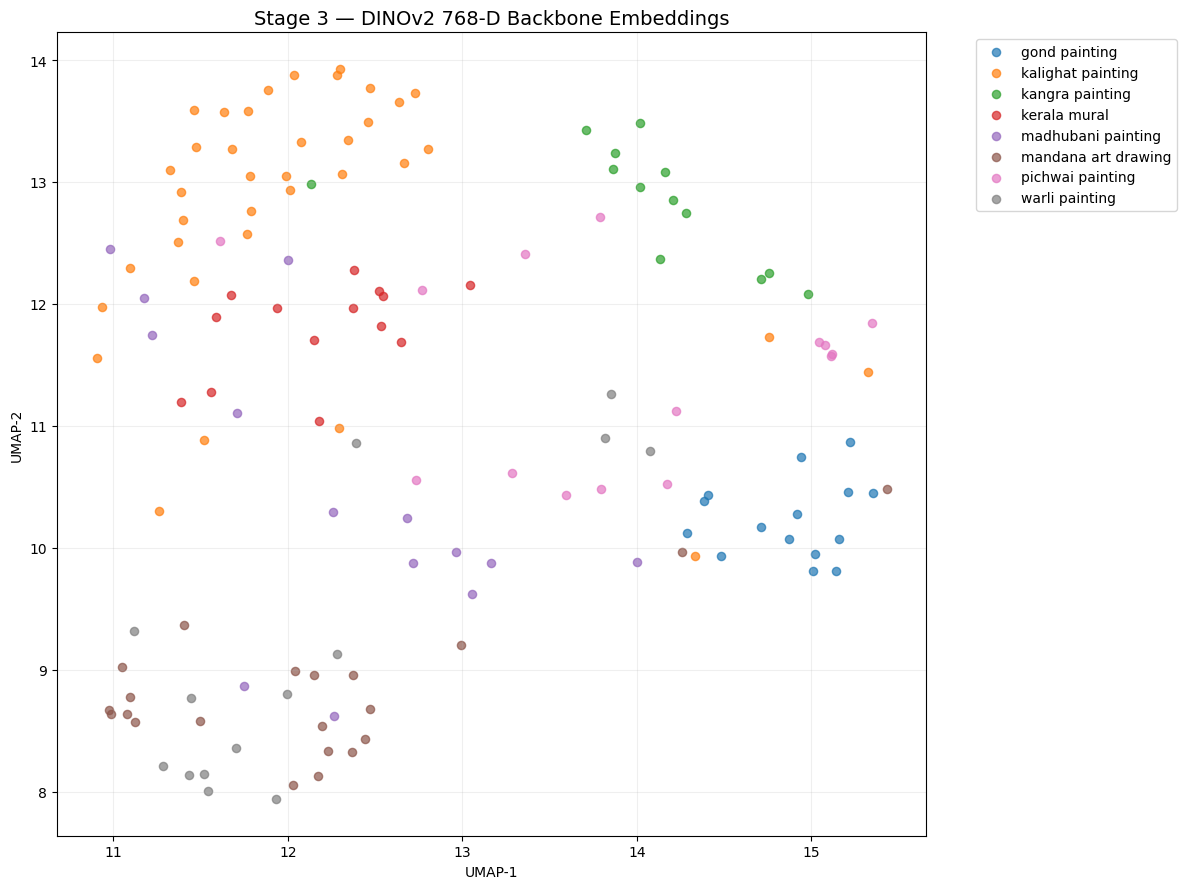

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


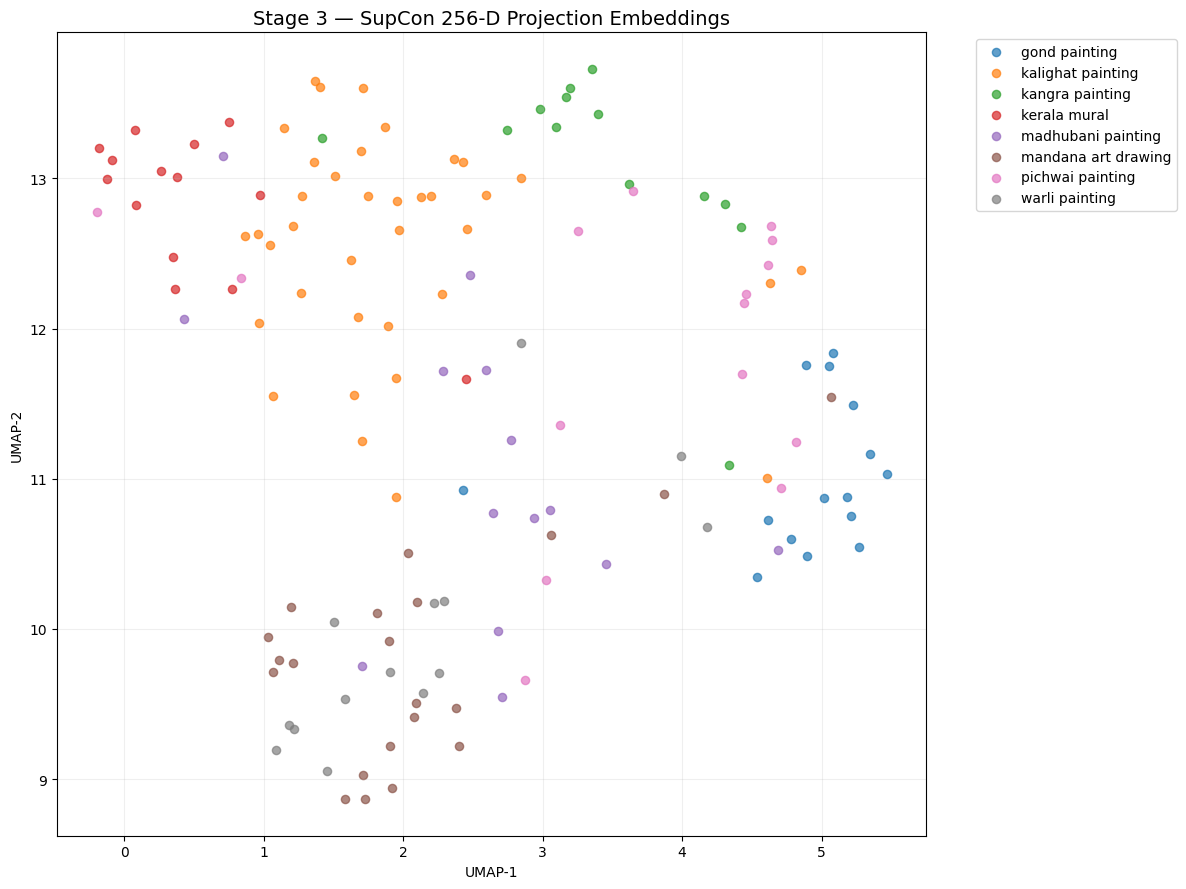

In [ ]:
# ============================================================
# CELL 29 — UMAP VISUALIZATION
# ============================================================

# ============================================================
# UMAP FUNCTION
# ============================================================

def plot_umap(
    embeddings,
    labels,
    title,
    random_state=SEED
):

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=random_state
    )

    embedding_2d = reducer.fit_transform(
        embeddings
    )

    plt.figure(
        figsize=(12, 9)
    )

    unique_labels = np.unique(labels)

    for class_idx in unique_labels:

        mask = labels == class_idx

        plt.scatter(
            embedding_2d[mask, 0],
            embedding_2d[mask, 1],
            label=class_names[class_idx],
            alpha=0.7,
            s=35
        )

    plt.title(
        title,
        fontsize=14
    )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.grid(
        alpha=0.2
    )

    plt.tight_layout()
    plt.show()

    return embedding_2d


# ============================================================
# DINOv2 BACKBONE SPACE
# ============================================================

stage3_backbone_umap = plot_umap(
    stage3_backbone_embeddings,
    stage3_labels,
    "Stage 3 — DINOv2 768-D Backbone Embeddings"
)


# ============================================================
# SUPCON PROJECTION SPACE
# ============================================================

stage3_projection_umap = plot_umap(
    stage3_projection_embeddings,
    stage3_projection_labels,
    "Stage 3 — SupCon 256-D Projection Embeddings"
)

In [ ]:
# ============================================================
# CELL 30 — STAGE 4
# PREPARE PARTIAL DINOv2 FINE-TUNING
# ============================================================

# ============================================================
# UNFREEZE LAST N TRANSFORMER BLOCKS
# ============================================================

UNFREEZE_LAST_N_BLOCKS = 2


# ------------------------------------------------------------
# First freeze the entire backbone
# ------------------------------------------------------------

for param in stage3_model.backbone.parameters():
    param.requires_grad = False


# ------------------------------------------------------------
# Inspect DINOv2 transformer blocks
# ------------------------------------------------------------

print("=" * 80)
print("DINOv2 BACKBONE STRUCTURE")
print("=" * 80)

print(
    "Number of transformer blocks:",
    len(stage3_model.backbone.blocks)
)


# ------------------------------------------------------------
# Unfreeze final N blocks
# ------------------------------------------------------------

num_blocks = len(
    stage3_model.backbone.blocks
)

start_block = max(
    0,
    num_blocks - UNFREEZE_LAST_N_BLOCKS
)

for block_idx in range(
    start_block,
    num_blocks
):

    for param in (
        stage3_model
        .backbone
        .blocks[block_idx]
        .parameters()
    ):
        param.requires_grad = True


# ------------------------------------------------------------
# Keep the classification and projection heads trainable
# ------------------------------------------------------------

for param in stage3_model.classifier.parameters():
    param.requires_grad = True

for param in stage3_model.projector.parameters():
    param.requires_grad = True


# ============================================================
# VERIFY TRAINABLE BLOCKS
# ============================================================

print("\n" + "=" * 80)
print("TRAINABLE TRANSFORMER BLOCKS")
print("=" * 80)

for idx, block in enumerate(
    stage3_model.backbone.blocks
):

    trainable = any(
        p.requires_grad
        for p in block.parameters()
    )

    status = (
        "TRAINABLE"
        if trainable
        else "FROZEN"
    )

    print(
        f"Block {idx:02d}: {status}"
    )


# ============================================================
# PARAMETER SUMMARY
# ============================================================

total_params = sum(
    p.numel()
    for p in stage3_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in stage3_model.parameters()
    if p.requires_grad
)

print("\n" + "=" * 80)
print("STAGE 4 PARAMETER SUMMARY")
print("=" * 80)

print(
    f"Total parameters     : {total_params:,}"
)

print(
    f"Trainable parameters : {trainable_params:,}"
)

print(
    f"Trainable percentage  : "
    f"{100 * trainable_params / total_params:.2f}%"
)

DINOv2 BACKBONE STRUCTURE
Number of transformer blocks: 12

TRAINABLE TRANSFORMER BLOCKS
Block 00: FROZEN
Block 01: FROZEN
Block 02: FROZEN
Block 03: FROZEN
Block 04: FROZEN
Block 05: FROZEN
Block 06: FROZEN
Block 07: FROZEN
Block 08: FROZEN
Block 09: FROZEN
Block 10: TRAINABLE
Block 11: TRAINABLE

STAGE 4 PARAMETER SUMMARY
Total parameters     : 87,503,368
Trainable parameters : 15,101,704
Trainable percentage  : 17.26%


In [ ]:
# ============================================================
# CELL 31 — STAGE 4 OPTIMIZER
# DISCRIMINATIVE LEARNING RATES
# ============================================================

# ============================================================
# LEARNING RATES
# ============================================================

BACKBONE_LR = 1e-5
HEAD_LR = 1e-4

WEIGHT_DECAY = 1e-4


# ============================================================
# COLLECT PARAMETERS
# ============================================================

backbone_params = []
head_params = []


# ------------------------------------------------------------
# Last trainable DINOv2 blocks
# ------------------------------------------------------------

for block_idx in range(
    start_block,
    num_blocks
):

    backbone_params.extend(
        [
            p
            for p in (
                stage3_model
                .backbone
                .blocks[block_idx]
                .parameters()
            )
            if p.requires_grad
        ]
    )


# ------------------------------------------------------------
# Classification head
# ------------------------------------------------------------

head_params.extend(
    [
        p
        for p in stage3_model
        .classifier
        .parameters()
        if p.requires_grad
    ]
)


# ------------------------------------------------------------
# Projection head
# ------------------------------------------------------------

head_params.extend(
    [
        p
        for p in stage3_model
        .projector
        .parameters()
        if p.requires_grad
    ]
)


# ============================================================
# CREATE OPTIMIZER
# ============================================================

stage4_optimizer = torch.optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": BACKBONE_LR
        },

        {
            "params": head_params,
            "lr": HEAD_LR
        }
    ],

    weight_decay=WEIGHT_DECAY
)


# ============================================================
# SUMMARY
# ============================================================

backbone_trainable = sum(
    p.numel()
    for p in backbone_params
)

head_trainable = sum(
    p.numel()
    for p in head_params
)

print("=" * 80)
print("STAGE 4 — DISCRIMINATIVE LEARNING RATES")
print("=" * 80)

print(
    f"DINOv2 trainable parameters : "
    f"{backbone_trainable:,}"
)

print(
    f"Head trainable parameters   : "
    f"{head_trainable:,}"
)

print(
    f"Total trainable parameters  : "
    f"{backbone_trainable + head_trainable:,}"
)

print("\nLearning rates:")
print(
    f"DINOv2 last {UNFREEZE_LAST_N_BLOCKS} blocks : "
    f"{BACKBONE_LR}"
)

print(
    f"Classification + Projection : "
    f"{HEAD_LR}"
)

print(
    f"Weight decay                : "
    f"{WEIGHT_DECAY}"
)

STAGE 4 — DISCRIMINATIVE LEARNING RATES
DINOv2 trainable parameters : 14,178,816
Head trainable parameters   : 922,888
Total trainable parameters  : 15,101,704

Learning rates:
DINOv2 last 2 blocks : 1e-05
Classification + Projection : 0.0001
Weight decay                : 0.0001


In [ ]:
# ============================================================
# CELL 32 — TRAIN STAGE 4
# PARTIAL DINOv2 FINE-TUNING + SUPCON
# ============================================================

STAGE4_EPOCHS = 15
STAGE4_PATIENCE = 4

print("=" * 80)
print("STAGE 4 — PARTIAL DINOv2 FINE-TUNING + SUPCON")
print("=" * 80)

print(
    f"Trainable DINOv2 blocks: "
    f"{start_block} → {num_blocks - 1}"
)

print(
    f"Backbone learning rate: "
    f"{BACKBONE_LR}"
)

print(
    f"Head learning rate: "
    f"{HEAD_LR}"
)

print(
    f"SupCon weight: "
    f"{SUPCON_WEIGHT}"
)

print()


# ============================================================
# TRAIN
# ============================================================

stage4_model, stage4_history = fit_supcon_model(
    model=stage3_model,
    train_loader=contrastive_train_loader,
    val_loader=val_loader,
    ce_criterion=nn.CrossEntropyLoss(),
    supcon_criterion=supcon_criterion,
    optimizer=stage4_optimizer,
    device=device,
    epochs=STAGE4_EPOCHS,
    patience=STAGE4_PATIENCE,
    ce_weight=CE_WEIGHT,
    supcon_weight=SUPCON_WEIGHT
)

print("\nStage 4 training complete.")

STAGE 4 — PARTIAL DINOv2 FINE-TUNING + SUPCON
Trainable DINOv2 blocks: 10 → 11
Backbone learning rate: 1e-05
Head learning rate: 0.0001
SupCon weight: 0.1



/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 01/15 | Total: 0.4505 | CE: 0.0515 | SupCon: 3.9901 | Train F1: 0.9906 | Val Acc: 0.8392 | Val F1: 0.8321


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 02/15 | Total: 0.4218 | CE: 0.0229 | SupCon: 3.9892 | Train F1: 0.9969 | Val Acc: 0.8881 | Val F1: 0.8744


...

Epoch 10/15 | Total: 0.4007 | CE: 0.0018 | SupCon: 3.9884 | Train F1: 1.0000 | Val Acc: 0.9231 | Val F1: 0.9161


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 11/15 | Total: 0.4004 | CE: 0.0016 | SupCon: 3.9888 | Train F1: 1.0000 | Val Acc: 0.9231 | Val F1: 0.9140


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 12/15 | Total: 0.3996 | CE: 0.0009 | SupCon: 3.9876 | Train F1: 1.0000 | Val Acc: 0.9231 | Val F1: 0.9161

Early stopping triggered after 12 epochs.

Best validation Macro-F1: 0.9224

Stage 4 training complete.


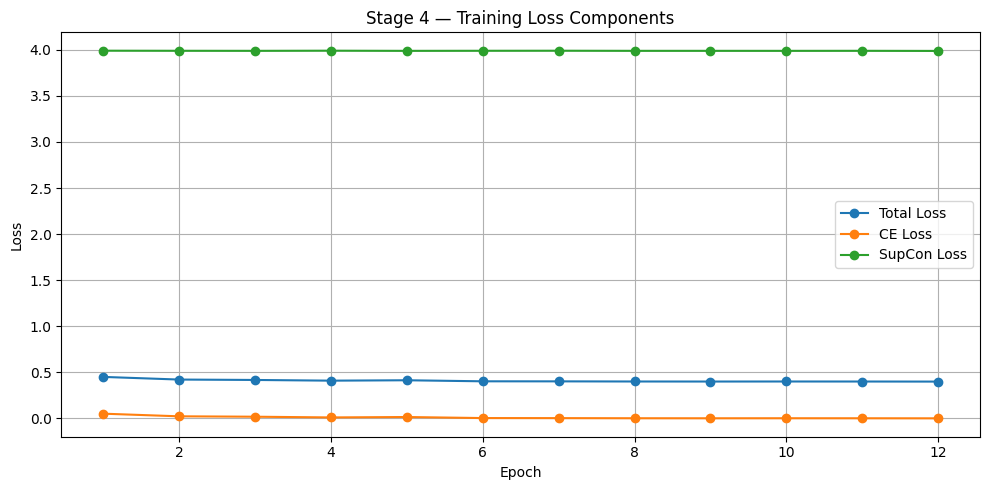

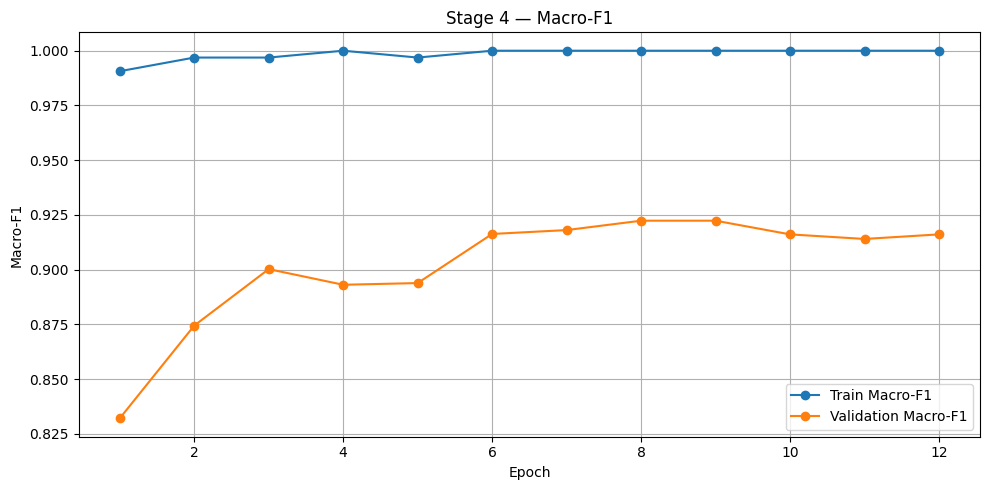

STAGE 3 vs STAGE 4


,Stage,Best Epoch,Validation Accuracy,Validation Macro-F1
0,Stage 3 — Frozen DINOv2 + SupCon,5,0.9161,0.9068
1,Stage 4 — Partial Fine-Tuning + SupCon,8,0.9301,0.9224



STAGE 4 IMPROVEMENT
Accuracy change : +0.0140
Macro-F1 change : +0.0156


In [ ]:
# ============================================================
# CELL 33 — STAGE 4 ANALYSIS
# ============================================================

# ============================================================
# BEST STAGE 4 RESULT
# ============================================================

stage4_best_idx = np.argmax(
    stage4_history["val_macro_f1"]
)

stage4_best_epoch = (
    stage4_best_idx + 1
)

stage4_best_accuracy = (
    stage4_history["val_accuracy"]
    [stage4_best_idx]
)

stage4_best_f1 = (
    stage4_history["val_macro_f1"]
    [stage4_best_idx]
)


# ============================================================
# STAGE 4 LEARNING CURVES
# ============================================================

epochs_ran = range(
    1,
    len(stage4_history["train_total_loss"]) + 1
)


# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_ran,
    stage4_history["train_total_loss"],
    marker="o",
    label="Total Loss"
)

plt.plot(
    epochs_ran,
    stage4_history["train_ce_loss"],
    marker="o",
    label="CE Loss"
)

plt.plot(
    epochs_ran,
    stage4_history["train_supcon_loss"],
    marker="o",
    label="SupCon Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Stage 4 — Training Loss Components"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Macro-F1
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_ran,
    stage4_history["train_macro_f1"],
    marker="o",
    label="Train Macro-F1"
)

plt.plot(
    epochs_ran,
    stage4_history["val_macro_f1"],
    marker="o",
    label="Validation Macro-F1"
)

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")

plt.title(
    "Stage 4 — Macro-F1"
)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# STAGE 3 vs STAGE 4
# ============================================================

stage3_best = get_best_history_result(
    stage3_history
)

stage4_result = {
    "Best Epoch": stage4_best_epoch,
    "Validation Accuracy": stage4_best_accuracy,
    "Validation Macro-F1": stage4_best_f1
}


comparison_stage3_stage4 = pd.DataFrame([
    {
        "Stage": "Stage 3 — Frozen DINOv2 + SupCon",
        **stage3_best
    },

    {
        "Stage": "Stage 4 — Partial Fine-Tuning + SupCon",
        **stage4_result
    }
])


print("=" * 100)
print("STAGE 3 vs STAGE 4")
print("=" * 100)

display(
    comparison_stage3_stage4.style.format({
        "Validation Accuracy": "{:.4f}",
        "Validation Macro-F1": "{:.4f}"
    })
)


# ============================================================
# IMPROVEMENT
# ============================================================

accuracy_delta = (
    stage4_result["Validation Accuracy"]
    - stage3_best["Validation Accuracy"]
)

f1_delta = (
    stage4_result["Validation Macro-F1"]
    - stage3_best["Validation Macro-F1"]
)

print("\n" + "=" * 100)
print("STAGE 4 IMPROVEMENT")
print("=" * 100)

print(
    f"Accuracy change : {accuracy_delta:+.4f}"
)

print(
    f"Macro-F1 change : {f1_delta:+.4f}"
)

In [ ]:
# ============================================================
# CELL 34 — EXTRACT STAGE 4 ADAPTED EMBEDDINGS
# ============================================================

# ============================================================
# EXTRACT ADAPTED DINOv2 BACKBONE FEATURES
# ============================================================

stage4_backbone_embeddings, stage4_labels = (
    extract_embeddings(
        stage4_model,
        val_loader,
        device,
        use_projection=False
    )
)


# ============================================================
# EXTRACT STAGE 4 SUPCON PROJECTION EMBEDDINGS
# ============================================================

stage4_projection_embeddings, stage4_projection_labels = (
    extract_embeddings(
        stage4_model,
        val_loader,
        device,
        use_projection=True
    )
)


# ============================================================
# VERIFY
# ============================================================

print("=" * 80)
print("STAGE 4 EMBEDDING EXTRACTION")
print("=" * 80)

print(
    "Adapted DINOv2 embedding shape :",
    stage4_backbone_embeddings.shape
)

print(
    "SupCon projection shape        :",
    stage4_projection_embeddings.shape
)

print(
    "Labels shape                   :",
    stage4_labels.shape
)

print("\n✓ Stage 4 embeddings extracted.")

STAGE 4 EMBEDDING EXTRACTION
Adapted DINOv2 embedding shape : (143, 768)
SupCon projection shape        : (143, 256)
Labels shape                   : (143,)

✓ Stage 4 embeddings extracted.


In [ ]:
# ============================================================
# CELL 35 — STAGE 3 vs STAGE 4 EMBEDDING ANALYSIS
# ============================================================

# ============================================================
# CALCULATE METRICS
# ============================================================

stage3_backbone_metrics = calculate_embedding_metrics(
    stage3_backbone_embeddings,
    stage3_labels
)

stage4_backbone_metrics = calculate_embedding_metrics(
    stage4_backbone_embeddings,
    stage4_labels
)


stage3_projection_metrics = calculate_embedding_metrics(
    stage3_projection_embeddings,
    stage3_projection_labels
)

stage4_projection_metrics = calculate_embedding_metrics(
    stage4_projection_embeddings,
    stage4_projection_labels
)


# ============================================================
# COMPARISON TABLE
# ============================================================

representation_comparison = pd.DataFrame([
    {
        "Representation": "Stage 3 DINOv2 Backbone",
        **stage3_backbone_metrics
    },

    {
        "Representation": "Stage 4 DINOv2 Backbone",
        **stage4_backbone_metrics
    },

    {
        "Representation": "Stage 3 SupCon Projection",
        **stage3_projection_metrics
    },

    {
        "Representation": "Stage 4 SupCon Projection",
        **stage4_projection_metrics
    }
])


print("=" * 115)
print("STAGE 3 vs STAGE 4 — REPRESENTATION QUALITY")
print("=" * 115)

display(
    representation_comparison.style.format({
        "Silhouette Score": "{:.4f}",
        "Davies-Bouldin Index": "{:.4f}",
        "Mean Intra-Class Distance": "{:.4f}",
        "Mean Inter-Class Distance": "{:.4f}",
        "Inter/Intra Distance Ratio": "{:.4f}"
    })
)


# ============================================================
# BACKBONE IMPROVEMENT
# ============================================================

backbone_silhouette_delta = (
    stage4_backbone_metrics["Silhouette Score"]
    -
    stage3_backbone_metrics["Silhouette Score"]
)

backbone_db_delta = (
    stage4_backbone_metrics["Davies-Bouldin Index"]
    -
    stage3_backbone_metrics["Davies-Bouldin Index"]
)

backbone_ratio_delta = (
    stage4_backbone_metrics["Inter/Intra Distance Ratio"]
    -
    stage3_backbone_metrics["Inter/Intra Distance Ratio"]
)


print("\n" + "=" * 100)
print("ADAPTED DINOv2 REPRESENTATION CHANGE")
print("=" * 100)

print(
    f"Silhouette Score change       : "
    f"{backbone_silhouette_delta:+.4f}"
)

print(
    f"Davies-Bouldin change         : "
    f"{backbone_db_delta:+.4f}"
)

print(
    f"Inter/Intra Ratio change      : "
    f"{backbone_ratio_delta:+.4f}"
)


# ============================================================
# DISTANCE CHANGES
# ============================================================

intra_delta = (
    stage4_backbone_metrics["Mean Intra-Class Distance"]
    -
    stage3_backbone_metrics["Mean Intra-Class Distance"]
)

inter_delta = (
    stage4_backbone_metrics["Mean Inter-Class Distance"]
    -
    stage3_backbone_metrics["Mean Inter-Class Distance"]
)

print(
    f"\nMean intra-class distance change : "
    f"{intra_delta:+.4f}"
)

print(
    f"Mean inter-class distance change : "
    f"{inter_delta:+.4f}"
)

STAGE 3 vs STAGE 4 — REPRESENTATION QUALITY


,Representation,Silhouette Score,Davies-Bouldin Index,Mean Intra-Class Distance,Mean Inter-Class Distance,Inter/Intra Distance Ratio
0,Stage 3 DINOv2 Backbone,0.0356,3.2010,46.3168,53.3116,1.1510
1,Stage 4 DINOv2 Backbone,0.0553,3.0026,52.0445,59.2578,1.1386
2,Stage 3 SupCon Projection,0.0245,2.9621,0.0849,0.1061,1.2495
3,Stage 4 SupCon Projection,0.0198,2.9146,0.0961,0.1141,1.1875



ADAPTED DINOv2 REPRESENTATION CHANGE
Silhouette Score change       : +0.0196
Davies-Bouldin change         : -0.1985
Inter/Intra Ratio change      : -0.0124

Mean intra-class distance change : +5.7277
Mean inter-class distance change : +5.9462


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


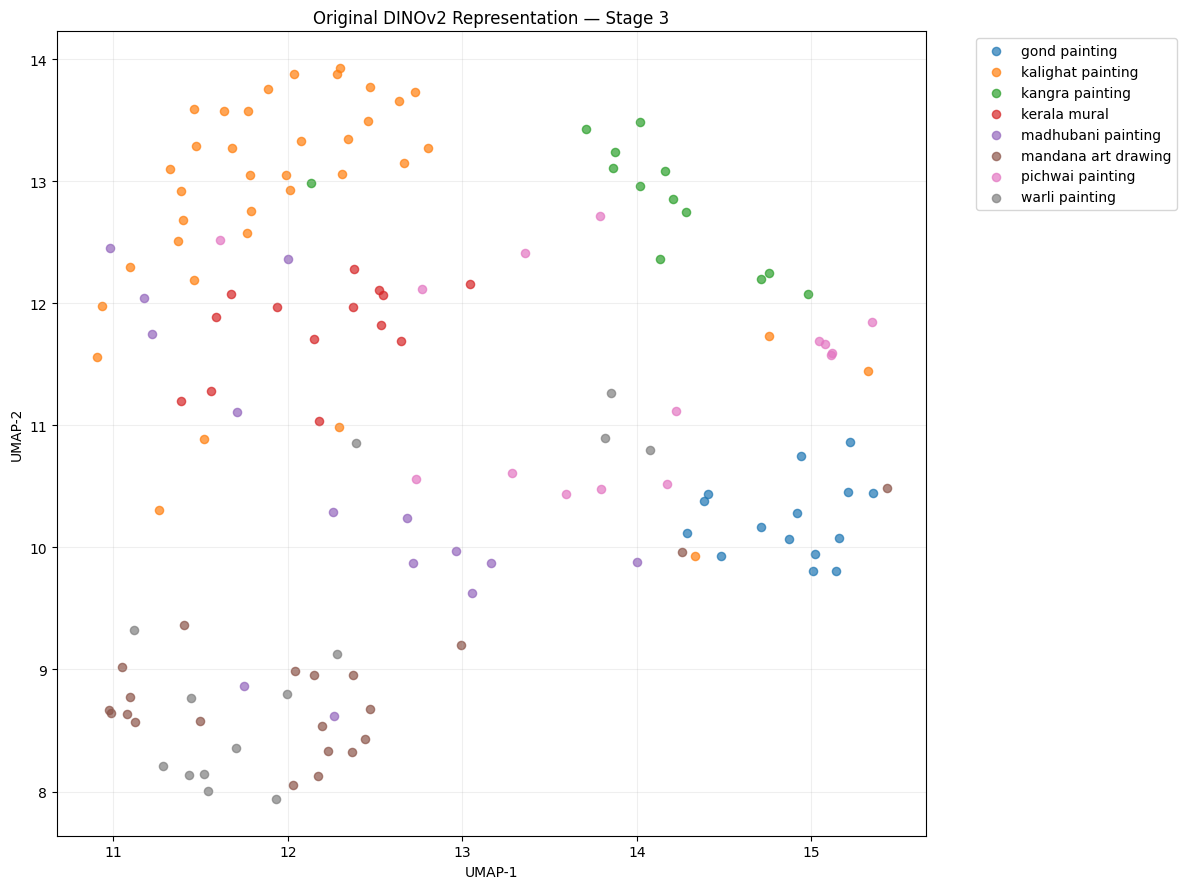

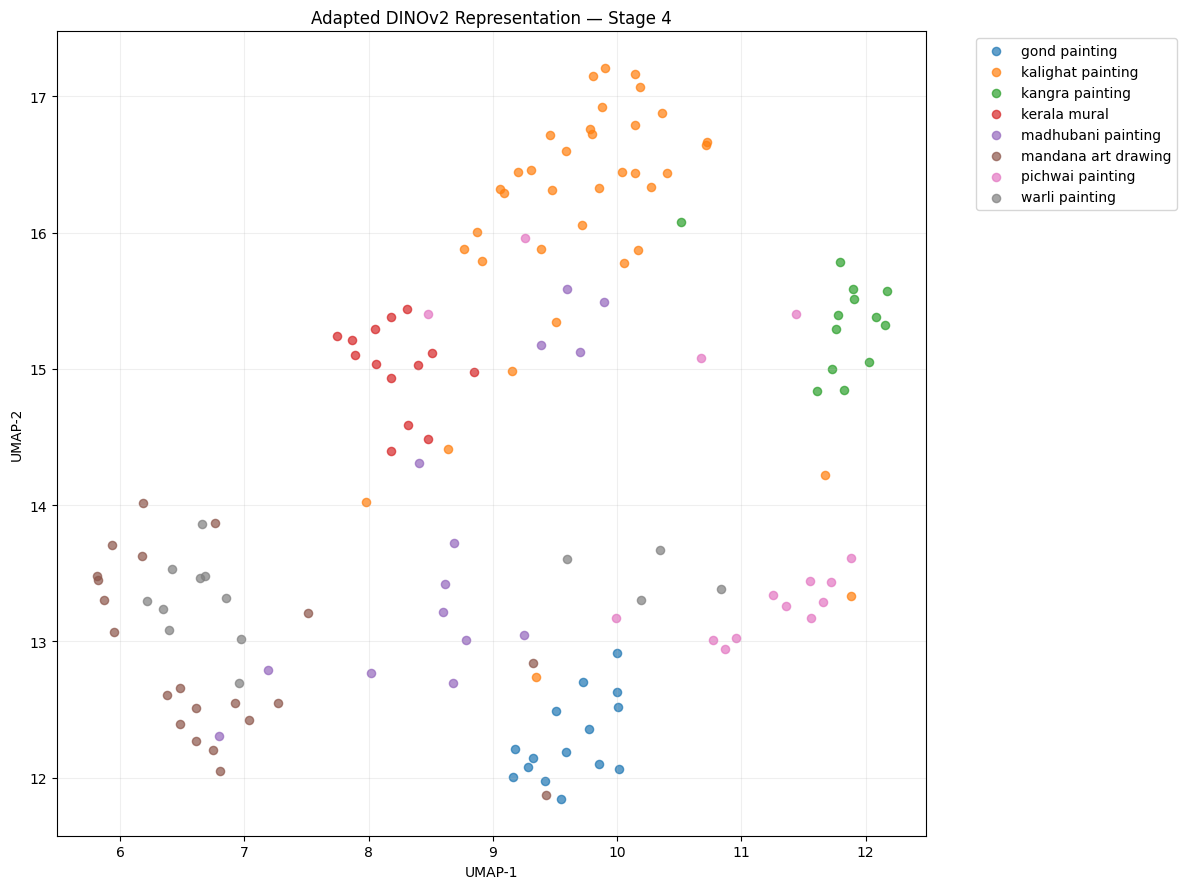

In [ ]:
# ============================================================
# CELL 36 — UMAP COMPARISON
# ORIGINAL vs ADAPTED DINOv2
# ============================================================

# ============================================================
# CREATE COMMON UMAP PROJECTION
# ============================================================
#
# IMPORTANT:
# We fit UMAP separately for visualization clarity.
# Quantitative comparison remains based on Cell 35 metrics.
# ============================================================

stage3_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)

stage3_2d = stage3_umap.fit_transform(
    stage3_backbone_embeddings
)


stage4_umap = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=SEED
)

stage4_2d = stage4_umap.fit_transform(
    stage4_backbone_embeddings
)


# ============================================================
# PLOT ORIGINAL DINOv2
# ============================================================

plt.figure(
    figsize=(12, 9)
)

for class_idx in np.unique(stage3_labels):

    mask = (
        stage3_labels == class_idx
    )

    plt.scatter(
        stage3_2d[mask, 0],
        stage3_2d[mask, 1],
        label=class_names[class_idx],
        alpha=0.7,
        s=35
    )

plt.title(
    "Original DINOv2 Representation — Stage 3"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ============================================================
# PLOT ADAPTED DINOv2
# ============================================================

plt.figure(
    figsize=(12, 9)
)

for class_idx in np.unique(stage4_labels):

    mask = (
        stage4_labels == class_idx
    )

    plt.scatter(
        stage4_2d[mask, 0],
        stage4_2d[mask, 1],
        label=class_names[class_idx],
        alpha=0.7,
        s=35
    )

plt.title(
    "Adapted DINOv2 Representation — Stage 4"
)

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

STAGE 4 — VALIDATION CLASSIFICATION REPORT
                     precision    recall  f1-score   support

      gond painting     0.9375    1.0000    0.9677        15
  kalighat painting     0.9730    0.9730    0.9730        37
    kangra painting     0.9286    1.0000    0.9630        13
       kerala mural     1.0000    0.9286    0.9630        14
 madhubani painting     0.8571    0.8571    0.8571        14
mandana art drawing     0.8696    0.9524    0.9091        21
   pichwai painting     0.9231    0.8000    0.8571        15
     warli painting     0.9231    0.8571    0.8889        14

           accuracy                         0.9301       143
          macro avg     0.9265    0.9210    0.9224       143
       weighted avg     0.9312    0.9301    0.9294       143

STAGE 4 — VALIDATION SUMMARY
Accuracy          : 0.9301
Macro-F1          : 0.9224
Weighted-F1       : 0.9294
Balanced Accuracy : 0.9210


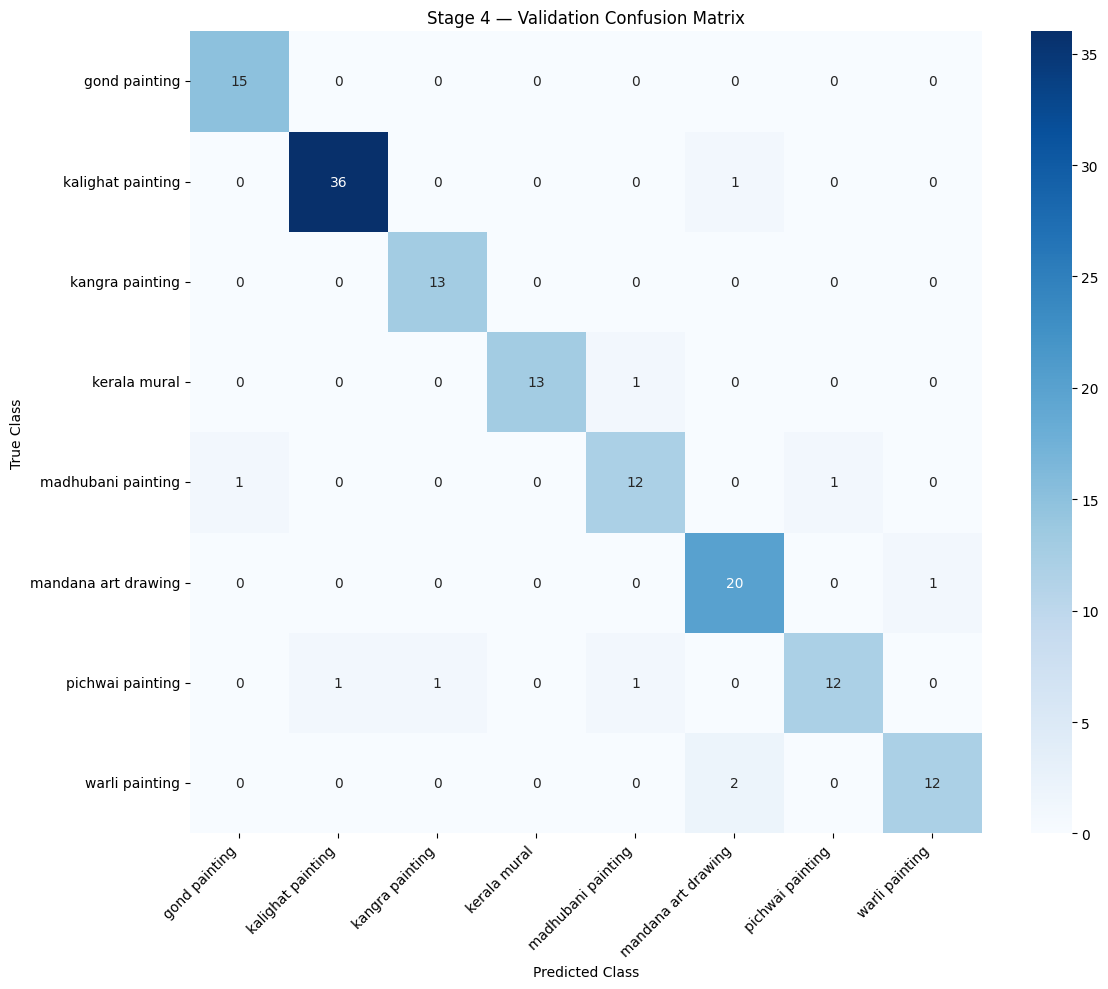

In [ ]:
# ============================================================
# CELL 37 — STAGE 4 VALIDATION EVALUATION
# FIXED FOR DINOv2 + SUPCON MODEL
# ============================================================

@torch.no_grad()
def get_supcon_predictions(
    model,
    loader,
    device
):
    model.eval()

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # SupCon model returns:
        # logits, projection
        # ----------------------------------------------------

        logits, _ = model(images)

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )


# ============================================================
# GET STAGE 4 VALIDATION PREDICTIONS
# ============================================================

stage4_val_labels, stage4_val_predictions = (
    get_supcon_predictions(
        stage4_model,
        val_loader,
        device
    )
)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("=" * 100)
print("STAGE 4 — VALIDATION CLASSIFICATION REPORT")
print("=" * 100)

print(
    classification_report(
        stage4_val_labels,
        stage4_val_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# SUMMARY METRICS
# ============================================================

stage4_val_accuracy = accuracy_score(
    stage4_val_labels,
    stage4_val_predictions
)

stage4_val_macro_f1 = f1_score(
    stage4_val_labels,
    stage4_val_predictions,
    average="macro"
)

stage4_val_weighted_f1 = f1_score(
    stage4_val_labels,
    stage4_val_predictions,
    average="weighted"
)

stage4_val_balanced_accuracy = balanced_accuracy_score(
    stage4_val_labels,
    stage4_val_predictions
)


print("=" * 100)
print("STAGE 4 — VALIDATION SUMMARY")
print("=" * 100)

print(
    f"Accuracy          : "
    f"{stage4_val_accuracy:.4f}"
)

print(
    f"Macro-F1          : "
    f"{stage4_val_macro_f1:.4f}"
)

print(
    f"Weighted-F1       : "
    f"{stage4_val_weighted_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{stage4_val_balanced_accuracy:.4f}"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

stage4_cm = confusion_matrix(
    stage4_val_labels,
    stage4_val_predictions
)

plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    stage4_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Stage 4 — Validation Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 38 — PER-CLASS STAGE 3 vs STAGE 4 COMPARISON
# ============================================================

# ============================================================
# GENERATE CLASSIFICATION REPORTS
# ============================================================

stage3_report = classification_report(
    val_labels,
    val_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

stage4_report = classification_report(
    stage4_val_labels,
    stage4_val_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)


# ============================================================
# BUILD COMPARISON TABLE
# ============================================================

per_class_comparison = []

for class_name in class_names:

    stage3_f1 = stage3_report[
        class_name
    ]["f1-score"]

    stage4_f1 = stage4_report[
        class_name
    ]["f1-score"]

    stage3_precision = stage3_report[
        class_name
    ]["precision"]

    stage4_precision = stage4_report[
        class_name
    ]["precision"]

    stage3_recall = stage3_report[
        class_name
    ]["recall"]

    stage4_recall = stage4_report[
        class_name
    ]["recall"]

    per_class_comparison.append({

        "Class": class_name,

        "Stage 3 Precision":
            stage3_precision,

        "Stage 4 Precision":
            stage4_precision,

        "Precision Change":
            stage4_precision - stage3_precision,

        "Stage 3 Recall":
            stage3_recall,

        "Stage 4 Recall":
            stage4_recall,

        "Recall Change":
            stage4_recall - stage3_recall,

        "Stage 3 F1":
            stage3_f1,

        "Stage 4 F1":
            stage4_f1,

        "F1 Change":
            stage4_f1 - stage3_f1
    })


per_class_df = pd.DataFrame(
    per_class_comparison
)


# ============================================================
# SORT BY F1 IMPROVEMENT
# ============================================================

per_class_df = per_class_df.sort_values(
    "F1 Change",
    ascending=False
).reset_index(drop=True)


# ============================================================
# DISPLAY
# ============================================================

print("=" * 120)
print("PER-CLASS PERFORMANCE — STAGE 3 vs STAGE 4")
print("=" * 120)

display(
    per_class_df.style.format({
        "Stage 3 Precision": "{:.4f}",
        "Stage 4 Precision": "{:.4f}",
        "Precision Change": "{:+.4f}",
        "Stage 3 Recall": "{:.4f}",
        "Stage 4 Recall": "{:.4f}",
        "Recall Change": "{:+.4f}",
        "Stage 3 F1": "{:.4f}",
        "Stage 4 F1": "{:.4f}",
        "F1 Change": "{:+.4f}"
    })
)


# ============================================================
# BEST / WORST IMPROVEMENTS
# ============================================================

print("\n" + "=" * 100)
print("LARGEST F1 IMPROVEMENTS")
print("=" * 100)

display(
    per_class_df[
        [
            "Class",
            "Stage 3 F1",
            "Stage 4 F1",
            "F1 Change"
        ]
    ].head(5).style.format({
        "Stage 3 F1": "{:.4f}",
        "Stage 4 F1": "{:.4f}",
        "F1 Change": "{:+.4f}"
    })
)


print("\n" + "=" * 100)
print("LARGEST F1 DECLINES")
print("=" * 100)

display(
    per_class_df[
        [
            "Class",
            "Stage 3 F1",
            "Stage 4 F1",
            "F1 Change"
        ]
    ].tail(5).sort_values(
        "F1 Change"
    ).style.format({
        "Stage 3 F1": "{:.4f}",
        "Stage 4 F1": "{:.4f}",
        "F1 Change": "{:+.4f}"
    })
)

PER-CLASS PERFORMANCE — STAGE 3 vs STAGE 4


,Class,Stage 3 Precision,Stage 4 Precision,Precision Change,Stage 3 Recall,Stage 4 Recall,Recall Change,Stage 3 F1,Stage 4 F1,F1 Change
0,warli painting,0.8462,0.9231,+0.0769,0.7857,0.8571,+0.0714,0.8148,0.8889,+0.0741
1,mandana art drawing,0.7917,0.8696,+0.0779,0.9048,0.9524,+0.0476,0.8444,0.9091,+0.0646
2,pichwai painting,0.8125,0.9231,+0.1106,0.8667,0.8000,-0.0667,0.8387,0.8571,+0.0184
3,kalighat painting,1.0000,0.9730,-0.0270,0.9459,0.9730,+0.0270,0.9722,0.9730,+0.0008
4,kangra painting,0.9286,0.9286,+0.0000,1.0000,1.0000,+0.0000,0.9630,0.9630,+0.0000
5,kerala mural,1.0000,1.0000,+0.0000,0.9286,0.9286,+0.0000,0.9630,0.9630,+0.0000
6,madhubani painting,0.9231,0.8571,-0.0659,0.8571,0.8571,+0.0000,0.8889,0.8571,-0.0317
7,gond painting,1.0000,0.9375,-0.0625,1.0000,1.0000,+0.0000,1.0000,0.9677,-0.0323



LARGEST F1 IMPROVEMENTS


,Class,Stage 3 F1,Stage 4 F1,F1 Change
0,warli painting,0.8148,0.8889,+0.0741
1,mandana art drawing,0.8444,0.9091,+0.0646
2,pichwai painting,0.8387,0.8571,+0.0184
3,kalighat painting,0.9722,0.9730,+0.0008
4,kangra painting,0.9630,0.9630,+0.0000



LARGEST F1 DECLINES


,Class,Stage 3 F1,Stage 4 F1,F1 Change
7,gond painting,1.0000,0.9677,-0.0323
6,madhubani painting,0.8889,0.8571,-0.0317
5,kerala mural,0.9630,0.9630,+0.0000
4,kangra painting,0.9630,0.9630,+0.0000
3,kalighat painting,0.9722,0.9730,+0.0008


In [ ]:
# ============================================================
# CELL 39 — FINAL STAGE COMPARISON
# CLASSIFICATION ONLY
# ============================================================

# ============================================================
# COLLECT BEST VALIDATION RESULTS
# ============================================================

stage1_best = get_best_history_result(
    stage1_history
)

stage2_best = get_best_history_result(
    stage2_history
)

stage3_best = get_best_history_result(
    stage3_history
)

stage4_best = get_best_history_result(
    stage4_history
)


# ============================================================
# BUILD FINAL COMPARISON TABLE
# ============================================================

final_stage_comparison = pd.DataFrame([

    {
        "Stage": "Stage 1",
        "Method": "Frozen DINOv2 + Linear",
        "Backbone": "Frozen",
        "SupCon": "No",
        **stage1_best
    },

    {
        "Stage": "Stage 2",
        "Method": "Frozen DINOv2 + MLP",
        "Backbone": "Frozen",
        "SupCon": "No",
        **stage2_best
    },

    {
        "Stage": "Stage 3",
        "Method": "Frozen DINOv2 + SupCon",
        "Backbone": "Frozen",
        "SupCon": "Yes",
        **stage3_best
    },

    {
        "Stage": "Stage 4",
        "Method": "Partial Fine-tuned DINOv2 + SupCon",
        "Backbone": "Last 2 Blocks",
        "SupCon": "Yes",
        **stage4_best
    }
])


# ============================================================
# DISPLAY
# ============================================================

print("=" * 110)
print("PIPELINE 4 — STAGE-WISE CLASSIFICATION COMPARISON")
print("=" * 110)

display(
    final_stage_comparison.style.format({
        "Validation Accuracy": "{:.4f}",
        "Validation Macro-F1": "{:.4f}"
    })
)


# ============================================================
# BEST STAGE
# ============================================================

best_stage_idx = final_stage_comparison[
    "Validation Macro-F1"
].idxmax()

best_stage = final_stage_comparison.loc[
    best_stage_idx
]


print("\n" + "=" * 110)
print("BEST PIPELINE 4 STAGE")
print("=" * 110)

print(
    "Stage:",
    best_stage["Stage"]
)

print(
    "Method:",
    best_stage["Method"]
)

print(
    f"Validation Accuracy: "
    f"{best_stage['Validation Accuracy']:.4f}"
)

print(
    f"Validation Macro-F1: "
    f"{best_stage['Validation Macro-F1']:.4f}"
)

PIPELINE 4 — STAGE-WISE CLASSIFICATION COMPARISON


,Stage,Method,Backbone,SupCon,Best Epoch,Validation Accuracy,Validation Macro-F1
0,Stage 1,Frozen DINOv2 + Linear,Frozen,No,10,0.9161,0.9106
1,Stage 2,Frozen DINOv2 + MLP,Frozen,No,4,0.9091,0.9054
2,Stage 3,Frozen DINOv2 + SupCon,Frozen,Yes,5,0.9161,0.9068
3,Stage 4,Partial Fine-tuned DINOv2 + SupCon,Last 2 Blocks,Yes,8,0.9301,0.9224



BEST PIPELINE 4 STAGE
Stage: Stage 4
Method: Partial Fine-tuned DINOv2 + SupCon
Validation Accuracy: 0.9301
Validation Macro-F1: 0.9224


In [ ]:
# ============================================================
# CELL 40 — LOCK FINAL CANDIDATE + TEST EVALUATION SETUP
# ============================================================

# ============================================================
# SELECT BEST STAGE
# ============================================================

BEST_STAGE = "Stage 4"

FINAL_MODEL = stage4_model


# ============================================================
# LOCK EXPERIMENT CONFIGURATION
# ============================================================

FINAL_CONFIG = {
    "model": "DINOv2 ViT-B/14",
    "training_strategy": "Supervised Contrastive Learning",
    "fine_tuning": "Last 2 Transformer Blocks",
    "projection_dimension": 256,
    "image_size": IMAGE_SIZE,
    "ce_weight": CE_WEIGHT,
    "supcon_weight": SUPCON_WEIGHT,
    "temperature": supcon_criterion.temperature,
    "backbone_lr": BACKBONE_LR,
    "head_lr": HEAD_LR,
    "seed": SEED
}


# ============================================================
# DISPLAY FINAL CONFIGURATION
# ============================================================

print("=" * 100)
print("FINAL PIPELINE 4 CANDIDATE")
print("=" * 100)

for key, value in FINAL_CONFIG.items():
    print(f"{key:<25}: {value}")


# ============================================================
# VERIFY TEST SET
# ============================================================

print("\n" + "=" * 100)
print("HELD-OUT TEST SET")
print("=" * 100)

print("Test images:", len(test_df))
print("Test classes:", test_df["class_name"].nunique())

print("\nTest class distribution:")

print(
    test_df["class_name"]
    .value_counts()
    .sort_index()
)


# ============================================================
# TEST LOADER CHECK
# ============================================================

print("\n" + "=" * 100)
print("TEST LOADER")
print("=" * 100)

print("Test batches:", len(test_loader))
print("Test batch size:", BATCH_SIZE)

print("\n✓ Test set has not been used for model selection.")
print("✓ Final candidate model is locked.")
print("✓ Ready for final test evaluation.")

FINAL PIPELINE 4 CANDIDATE
model                    : DINOv2 ViT-B/14
training_strategy        : Supervised Contrastive Learning
fine_tuning              : Last 2 Transformer Blocks
projection_dimension     : 256
image_size               : 224
ce_weight                : 1.0
supcon_weight            : 0.1
temperature              : 0.07
backbone_lr              : 1e-05
head_lr                  : 0.0001
seed                     : 42

HELD-OUT TEST SET
Test images: 143
Test classes: 8

Test class distribution:
class_name
gond painting          15
kalighat painting      37
kangra painting        13
kerala mural           14
madhubani painting     14
mandana art drawing    21
pichwai painting       14
warli painting         15
Name: count, dtype: int64

TEST LOADER
Test batches: 5
Test batch size: 32

✓ Test set has not been used for model selection.
✓ Final candidate model is locked.
✓ Ready for final test evaluation.


PIPELINE 4 — FINAL TEST CLASSIFICATION REPORT
                     precision    recall  f1-score   support

      gond painting     0.9333    0.9333    0.9333        15
  kalighat painting     0.9737    1.0000    0.9867        37
    kangra painting     1.0000    0.9231    0.9600        13
       kerala mural     1.0000    1.0000    1.0000        14
 madhubani painting     0.8667    0.9286    0.8966        14
mandana art drawing     0.9000    0.8571    0.8780        21
   pichwai painting     1.0000    0.8571    0.9231        14
     warli painting     0.8824    1.0000    0.9375        15

           accuracy                         0.9441       143
          macro avg     0.9445    0.9374    0.9394       143
       weighted avg     0.9461    0.9441    0.9438       143

PIPELINE 4 — FINAL TEST RESULTS
Accuracy          : 0.9441 (94.41%)
Macro-F1          : 0.9394
Weighted-F1       : 0.9438
Balanced Accuracy : 0.9374


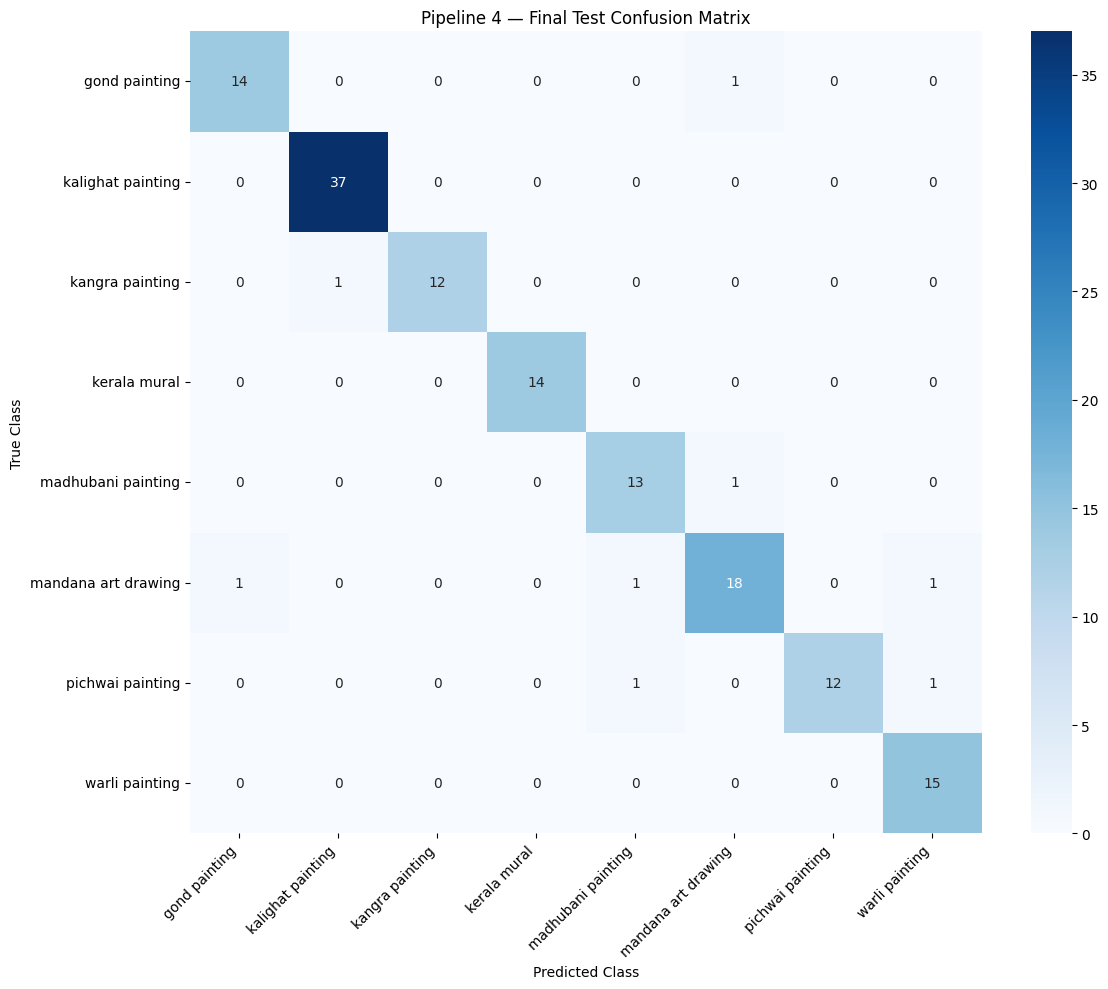

In [ ]:
# ============================================================
# CELL 41 — FINAL HELD-OUT TEST EVALUATION
# ============================================================

# ============================================================
# GET TEST PREDICTIONS
# ============================================================

final_test_labels, final_test_predictions = (
    get_supcon_predictions(
        FINAL_MODEL,
        test_loader,
        device
    )
)


# ============================================================
# CALCULATE FINAL METRICS
# ============================================================

final_test_accuracy = accuracy_score(
    final_test_labels,
    final_test_predictions
)

final_test_macro_f1 = f1_score(
    final_test_labels,
    final_test_predictions,
    average="macro"
)

final_test_weighted_f1 = f1_score(
    final_test_labels,
    final_test_predictions,
    average="weighted"
)

final_test_balanced_accuracy = balanced_accuracy_score(
    final_test_labels,
    final_test_predictions
)


# ============================================================
# FINAL CLASSIFICATION REPORT
# ============================================================

print("=" * 110)
print("PIPELINE 4 — FINAL TEST CLASSIFICATION REPORT")
print("=" * 110)

print(
    classification_report(
        final_test_labels,
        final_test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# FINAL SUMMARY
# ============================================================

print("=" * 110)
print("PIPELINE 4 — FINAL TEST RESULTS")
print("=" * 110)

print(
    f"Accuracy          : "
    f"{final_test_accuracy:.4f} "
    f"({final_test_accuracy * 100:.2f}%)"
)

print(
    f"Macro-F1          : "
    f"{final_test_macro_f1:.4f}"
)

print(
    f"Weighted-F1       : "
    f"{final_test_weighted_f1:.4f}"
)

print(
    f"Balanced Accuracy : "
    f"{final_test_balanced_accuracy:.4f}"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

final_test_cm = confusion_matrix(
    final_test_labels,
    final_test_predictions
)


plt.figure(
    figsize=(12, 10)
)

sns.heatmap(
    final_test_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Pipeline 4 — Final Test Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "True Class"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 42 — FINAL TEST PER-CLASS ANALYSIS
# ============================================================

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

final_test_report = classification_report(
    final_test_labels,
    final_test_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)


# ============================================================
# BUILD TABLE
# ============================================================

final_per_class = []

for class_name in class_names:

    metrics = final_test_report[class_name]

    final_per_class.append({

        "Class": class_name,

        "Precision":
            metrics["precision"],

        "Recall":
            metrics["recall"],

        "F1":
            metrics["f1-score"],

        "Support":
            int(metrics["support"])
    })


final_per_class_df = pd.DataFrame(
    final_per_class
)


# ============================================================
# SORT BY F1
# ============================================================

final_per_class_df = (
    final_per_class_df
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)


# ============================================================
# DISPLAY
# ============================================================

print("=" * 100)
print("PIPELINE 4 — FINAL TEST PER-CLASS PERFORMANCE")
print("=" * 100)

display(
    final_per_class_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)


# ============================================================
# BEST / WEAKEST CLASSES
# ============================================================

best_class = final_per_class_df.iloc[0]

worst_class = final_per_class_df.iloc[-1]


print("\n" + "=" * 100)
print("BEST PERFORMING CLASS")
print("=" * 100)

print(
    f"Class    : {best_class['Class']}"
)

print(
    f"Precision: {best_class['Precision']:.4f}"
)

print(
    f"Recall   : {best_class['Recall']:.4f}"
)

print(
    f"F1       : {best_class['F1']:.4f}"
)


print("\n" + "=" * 100)
print("WEAKEST PERFORMING CLASS")
print("=" * 100)

print(
    f"Class    : {worst_class['Class']}"
)

print(
    f"Precision: {worst_class['Precision']:.4f}"
)

print(
    f"Recall   : {worst_class['Recall']:.4f}"
)

print(
    f"F1       : {worst_class['F1']:.4f}"
)

print(
    f"Support  : {int(worst_class['Support'])}"
)

PIPELINE 4 — FINAL TEST PER-CLASS PERFORMANCE


,Class,Precision,Recall,F1,Support
0,kerala mural,1.0000,1.0000,1.0000,14
1,kalighat painting,0.9737,1.0000,0.9867,37
2,kangra painting,1.0000,0.9231,0.9600,13
3,warli painting,0.8824,1.0000,0.9375,15
4,gond painting,0.9333,0.9333,0.9333,15
5,pichwai painting,1.0000,0.8571,0.9231,14
6,madhubani painting,0.8667,0.9286,0.8966,14
7,mandana art drawing,0.9000,0.8571,0.8780,21



BEST PERFORMING CLASS
Class    : kerala mural
Precision: 1.0000
Recall   : 1.0000
F1       : 1.0000

WEAKEST PERFORMING CLASS
Class    : mandana art drawing
Precision: 0.9000
Recall   : 0.8571
F1       : 0.8780
Support  : 21


In [ ]:
# ============================================================
# CELL 43 — FINAL TEST ERROR ANALYSIS
# ============================================================

# ============================================================
# CONFUSION MATRIX
# ============================================================

final_cm = confusion_matrix(
    final_test_labels,
    final_test_predictions
)


# ============================================================
# EXTRACT OFF-DIAGONAL ERRORS
# ============================================================

error_pairs = []

for true_idx in range(num_classes):

    for pred_idx in range(num_classes):

        # Ignore correct predictions
        if true_idx == pred_idx:
            continue

        error_count = final_cm[
            true_idx,
            pred_idx
        ]

        if error_count > 0:

            error_pairs.append({

                "True Class":
                    class_names[true_idx],

                "Predicted Class":
                    class_names[pred_idx],

                "Errors":
                    int(error_count)
            })


# ============================================================
# SORT BY ERROR COUNT
# ============================================================

error_pairs_df = pd.DataFrame(
    error_pairs
)

if len(error_pairs_df) > 0:

    error_pairs_df = (
        error_pairs_df
        .sort_values(
            "Errors",
            ascending=False
        )
        .reset_index(drop=True)
    )


# ============================================================
# DISPLAY
# ============================================================

print("=" * 100)
print("PIPELINE 4 — MOST FREQUENT TEST-SET CONFUSIONS")
print("=" * 100)

if len(error_pairs_df) > 0:

    display(
        error_pairs_df.head(15)
    )

else:

    print(
        "No classification errors found."
    )


# ============================================================
# TOTAL ERRORS
# ============================================================

total_errors = np.sum(
    final_test_labels != final_test_predictions
)

total_samples = len(
    final_test_labels
)

print("\n" + "=" * 100)
print("ERROR SUMMARY")
print("=" * 100)

print(
    f"Total test samples : {total_samples}"
)

print(
    f"Correct predictions : "
    f"{total_samples - total_errors}"
)

print(
    f"Incorrect predictions: "
    f"{total_errors}"
)

print(
    f"Error rate          : "
    f"{total_errors / total_samples:.4f}"
)

PIPELINE 4 — MOST FREQUENT TEST-SET CONFUSIONS


,True Class,Predicted Class,Errors
0,gond painting,mandana art drawing,1
1,kangra painting,kalighat painting,1
2,madhubani painting,mandana art drawing,1
3,mandana art drawing,gond painting,1
4,mandana art drawing,madhubani painting,1
5,mandana art drawing,warli painting,1
6,pichwai painting,madhubani painting,1
7,pichwai painting,warli painting,1



ERROR SUMMARY
Total test samples : 143
Correct predictions : 135
Incorrect predictions: 8
Error rate          : 0.0559
